# ST_Pat4_51: Clustering-Based Phenotyping

This notebook adapts `01_dev_clustering_based_phenotyping_test.ipynb` to the ST_Pat4_51 CellDive data. It starts from the QC-filtered AnnData produced by `00_ST_Pat4_51_qc.ipynb`, uses the true channel order from `markers_bs.csv`, and writes clustering/phenotyping outputs into the ST_Pat4_51 project folder.

Main steps:

1. Load the QC-filtered AnnData and validate the marker order.
2. Z-score marker expression and run level-0 Leiden clustering.
3. Summarize clusters with marker-panel scores and write a review table.
4. Apply reviewed or draft phenotype names back to the AnnData object.
5. Optionally refine broad phenotypes after manual review.

## Runtime Setup

The cache directories are set before importing Scanpy/Numba. This avoids local cache-location errors that can happen when Jupyter is launched from different environments.

In [1]:
import os
from pathlib import Path
from dataclasses import asdict
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
os.environ.setdefault("NUMBA_CACHE_DIR", "/private/tmp/numba-cache")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["NUMBA_CACHE_DIR"]).mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import anndata as ad
from scipy import sparse
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex
from IPython.display import display

import scanpy as sc
import spatioev as sv
from spatioev.config import ClusteringConfig

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=120, facecolor="white", frameon=False)

print(f"Scanpy: {sc.__version__}")
print(f"SpatioEv: {getattr(sv, '__version__', 'unknown')}")

import importlib.util

VIEWER_DEPENDENCIES = {
    name: importlib.util.find_spec(name) is not None
    for name in ["napari", "scimap", "qtpy"]
}
VIEWER_AVAILABLE = all(VIEWER_DEPENDENCIES.values())
missing_viewer_deps = [name for name, available in VIEWER_DEPENDENCIES.items() if not available]

def patch_napari_cache(cache_dir="/private/tmp/napari-cache-spatioev"):
    """Redirect Napari's generated icon/theme cache to a writable folder."""
    cache_path = Path(cache_dir)
    cache_path.mkdir(parents=True, exist_ok=True)
    try:
        import napari.utils._appdirs as napari_appdirs
        napari_appdirs.user_cache_dir = lambda: str(cache_path)
        import napari.resources._icons as napari_icons
        napari_icons.user_cache_dir = lambda: str(cache_path)
    except Exception as exc:
        print(f"Napari cache patch warning: {exc}")
    return cache_path

def enable_qt_event_loop():
    ip = get_ipython() if "get_ipython" in globals() else None
    if ip is not None:
        try:
            ip.run_line_magic("gui", "qt")
        except Exception as exc:
            print(f"Could not enable Jupyter Qt event loop: {exc}")

def check_viewer_runtime():
    if not VIEWER_AVAILABLE:
        print(f"Viewer dependencies missing: {missing_viewer_deps}")
        return False
    patch_napari_cache()
    try:
        import napari
        import scimap
        import qtpy
        print(f"Viewer runtime OK: napari {napari.__version__}, scimap {scimap.__version__}, qtpy {qtpy.__version__}")
        return True
    except Exception as exc:
        print(f"Viewer runtime import failed: {type(exc).__name__}: {exc}")
        return False

def launch_napari_point_viewer(
    adata_obj,
    label,
    x_coordinate="X_centroid",
    y_coordinate="Y_centroid",
    point_size=4,
    alpha=0.85,
    max_points_per_layer=None,
    title=None,
):
    """Launch a lightweight Napari viewer with visible point layers by label."""
    if not check_viewer_runtime():
        return None
    enable_qt_event_loop()
    import napari

    if label not in adata_obj.obs.columns:
        raise ValueError(f"{label!r} is not in adata.obs")

    obs = adata_obj.obs[[x_coordinate, y_coordinate, label]].copy()
    obs[label] = obs[label].astype(str)
    categories = sorted(obs[label].dropna().unique(), key=lambda v: (0, int(v)) if str(v).isdigit() else (1, str(v)))

    viewer = napari.Viewer(title=title or label)
    cmap = plt.get_cmap("tab20", max(len(categories), 1))

    for i, category in enumerate(categories):
        part = obs[obs[label] == category]
        if max_points_per_layer is not None and len(part) > max_points_per_layer:
            part = part.sample(max_points_per_layer, random_state=RANDOM_STATE)
        points = part[[y_coordinate, x_coordinate]].to_numpy(dtype=float)
        color = to_hex(cmap(i % cmap.N), keep_alpha=False)
        viewer.add_points(
            points,
            name=f"{label}: {category}",
            size=point_size,
            face_color=color,
            edge_color=color,
            edge_width=0,
            opacity=alpha,
            visible=False,
        )

    viewer.reset_view()
    print("Napari point viewer launched with point layers hidden by default. If it is not in front, check the Dock or Window menu.")
    return viewer




def _overlay_points_on_viewer(
    viewer,
    adata_obj,
    label,
    x_coordinate="X_centroid",
    y_coordinate="Y_centroid",
    point_size=8,
    point_alpha=0.9,
):
    obs = adata_obj.obs[[x_coordinate, y_coordinate, label]].copy()
    obs[label] = obs[label].astype(str)
    categories = sorted(
        obs[label].dropna().unique(),
        key=lambda v: (0, int(v)) if str(v).isdigit() else (1, str(v)),
    )
    cmap = plt.get_cmap("tab20", max(len(categories), 1))

    for i, category in enumerate(categories):
        part = obs[obs[label] == category]
        points = part[[y_coordinate, x_coordinate]].to_numpy(dtype=float)
        color = to_hex(cmap(i % cmap.N), keep_alpha=False)
        viewer.add_points(
            points,
            name=f"{label}: {category}",
            size=point_size,
            face_color=color,
            edge_color=color,
            edge_width=0,
            opacity=point_alpha,
            visible=False,
        )
    return len(categories)



def _ellipse_contains_points(points_xy, vertices_yx):
    """Return mask for points inside a Napari ellipse shape."""
    vertices_xy = np.fliplr(np.asarray(vertices_yx, dtype=float))
    center = vertices_xy.mean(axis=0)
    centered = vertices_xy - center
    # Napari ellipse vertices are ordered as two axis endpoints and two co-axis endpoints.
    axis_a = vertices_xy[1] - vertices_xy[0]
    axis_b = vertices_xy[3] - vertices_xy[2]
    a = np.linalg.norm(axis_a) / 2
    b = np.linalg.norm(axis_b) / 2
    if a == 0 or b == 0:
        return np.zeros(points_xy.shape[0], dtype=bool)
    ux = axis_a / np.linalg.norm(axis_a)
    uy = axis_b / np.linalg.norm(axis_b)
    rel = points_xy - center
    x = rel @ ux
    y = rel @ uy
    return (x / a) ** 2 + (y / b) ** 2 <= 1


def _shape_contains_points(points_xy, vertices_yx, shape_type):
    from matplotlib.path import Path as MplPath

    shape_type = str(shape_type)
    if shape_type == "ellipse":
        return _ellipse_contains_points(points_xy, vertices_yx)
    if shape_type in {"polygon", "rectangle", "path"}:
        vertices_xy = np.fliplr(np.asarray(vertices_yx, dtype=float))
        return MplPath(vertices_xy, closed=True).contains_points(points_xy)
    return np.zeros(points_xy.shape[0], dtype=bool)


def _collect_roi_shapes(viewer, label):
    try:
        from napari.layers import Shapes
    except Exception:
        Shapes = None

    roi_shapes = []
    for layer in viewer.layers:
        is_shapes = isinstance(layer, Shapes) if Shapes is not None else layer.__class__.__name__ == "Shapes"
        if not is_shapes:
            continue
        if len(layer.data) == 0:
            continue
        roi_name = str(layer.name)
        for vertices, shape_type in zip(layer.data, layer.shape_type):
            roi_shapes.append(
                {
                    "ROI": roi_name,
                    "shape_type": str(shape_type),
                    "vertices_yx": np.asarray(vertices, dtype=float),
                }
            )
    return roi_shapes


def assign_cells_to_roi_shapes(
    adata_obj,
    roi_shapes,
    label="ROI",
    x_coordinate="X_centroid",
    y_coordinate="Y_centroid",
    default_label="Other",
):
    assigned = pd.Series(default_label, index=adata_obj.obs_names, dtype="object")
    points_xy = adata_obj.obs[[x_coordinate, y_coordinate]].to_numpy(dtype=float)

    for roi_shape in roi_shapes:
        mask = _shape_contains_points(points_xy, roi_shape["vertices_yx"], roi_shape["shape_type"])
        unassigned_mask = mask & (assigned.to_numpy() == default_label)
        assigned.iloc[np.where(unassigned_mask)[0]] = roi_shape["ROI"]

    out = adata_obj.copy()
    out.obs[label] = assigned.astype(str)
    return out


def add_rois_with_ome_zarr_viewer(
    image_path,
    adata_obj,
    channel_names,
    image_markers=None,
    label="ROI",
    x_coordinate="X_centroid",
    y_coordinate="Y_centroid",
    point_size=8,
    title=None,
):
    """Draw ROIs on the OME-Zarr in Napari and assign cells to the drawn shape layers."""
    if not check_viewer_runtime():
        return adata_obj
    enable_qt_event_loop()

    import dask.array as da
    import napari
    import zarr

    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(str(image_path))

    channel_names = list(channel_names)
    if image_markers is None:
        image_markers = [channel_names[0]]
    image_markers = [m for m in image_markers if m in channel_names]
    if not image_markers:
        raise ValueError("None of the requested image_markers were found in channel_names.")
    channel_idx = [channel_names.index(m) for m in image_markers]

    root = zarr.open_group(str(image_path), mode="r")
    multiscales = root.attrs.get("multiscales", [])
    if multiscales and multiscales[0].get("datasets"):
        level_paths = [dataset["path"] for dataset in multiscales[0]["datasets"]]
    else:
        level_paths = sorted(root.array_keys(), key=lambda key: int(key) if str(key).isdigit() else str(key))

    pyramid = []
    for level_path in level_paths:
        arr = da.from_zarr(root[level_path])
        if arr.ndim == 3:
            arr = arr[channel_idx, :, :]
        elif arr.ndim == 2:
            arr = arr[None, :, :]
        else:
            raise ValueError(f"Unexpected OME-Zarr level shape at {level_path}: {arr.shape}")
        pyramid.append(arr)

    viewer = napari.view_image(
        pyramid,
        multiscale=len(pyramid) > 1,
        channel_axis=0,
        name=image_markers,
        visible=False,
        blending="additive",
    )

    if title is not None:
        try:
            viewer.title = title
        except Exception:
            pass

    # Add cell points as a light reference layer, then initialize the ROI drawing layer.
    points_yx = adata_obj.obs[[y_coordinate, x_coordinate]].to_numpy(dtype=float)
    viewer.add_points(
        points_yx,
        name="cells",
        size=point_size,
        face_color="white",
        edge_color="white",
        edge_width=0,
        opacity=0.35,
        visible=False,
    )
    roi_layer = viewer.add_shapes(name=label)
    roi_layer.mode = "add_polygon"

    print("Opening Napari for ROI drawing.")
    print("Draw polygons/rectangles/ellipses in the Shapes layer. Rename each shape layer to the ROI label you want.")
    print("Add more Shapes layers for multiple ROI classes. Avoid overlapping ROIs. Close Napari to save ROI assignments.")
    viewer.show(block=True)

    roi_shapes = _collect_roi_shapes(viewer, label=label)
    if not roi_shapes:
        print("No ROI shapes were drawn. Existing ROI labels are unchanged.")
        return adata_obj

    print("Identifying cells within selected ROIs")
    out = assign_cells_to_roi_shapes(
        adata_obj,
        roi_shapes,
        label=label,
        x_coordinate=x_coordinate,
        y_coordinate=y_coordinate,
        default_label="Other",
    )
    print(f"ROIs saved under adata.obs[{label!r}]")
    return out

def launch_ome_zarr_overlay_viewer(
    adata_obj,
    image_path,
    label,
    channel_names,
    image_markers=None,
    x_coordinate="X_centroid",
    y_coordinate="Y_centroid",
    point_size=8,
    point_alpha=0.9,
    title=None,
):
    """Launch Napari with selected channels from the full-canvas OME-Zarr and visible point overlays."""
    if not check_viewer_runtime():
        return None
    enable_qt_event_loop()

    import dask.array as da
    import napari
    import zarr

    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(str(image_path))
    if label not in adata_obj.obs.columns:
        raise ValueError(f"{label!r} is not in adata.obs")

    channel_names = list(channel_names)
    if image_markers is None:
        image_markers = [channel_names[0]]
    image_markers = [m for m in image_markers if m in channel_names]
    if not image_markers:
        raise ValueError("None of the requested image_markers were found in channel_names.")
    channel_idx = [channel_names.index(m) for m in image_markers]

    root = zarr.open_group(str(image_path), mode="r")
    multiscales = root.attrs.get("multiscales", [])
    if multiscales and multiscales[0].get("datasets"):
        level_paths = [dataset["path"] for dataset in multiscales[0]["datasets"]]
    else:
        level_paths = sorted(root.array_keys(), key=lambda key: int(key) if str(key).isdigit() else str(key))

    pyramid = []
    for level_path in level_paths:
        arr = da.from_zarr(root[level_path])
        if arr.ndim == 3:
            arr = arr[channel_idx, :, :]
        elif arr.ndim == 2:
            arr = arr[None, :, :]
        else:
            raise ValueError(f"Unexpected OME-Zarr level shape at {level_path}: {arr.shape}")
        pyramid.append(arr)

    viewer = napari.view_image(
        pyramid,
        multiscale=len(pyramid) > 1,
        channel_axis=0,
        name=image_markers,
        visible=False,
        blending="additive",
    )

    if title is not None:
        try:
            viewer.title = title
        except Exception:
            pass

    n_point_layers = _overlay_points_on_viewer(
        viewer,
        adata_obj,
        label=label,
        x_coordinate=x_coordinate,
        y_coordinate=y_coordinate,
        point_size=point_size,
        point_alpha=point_alpha,
    )

    viewer.reset_view()
    print(f"Napari OME-Zarr viewer launched: {image_path}")
    print(f"Loaded image markers, hidden by default: {image_markers}")
    print(f"Loaded point layers, hidden by default for {label}: {n_point_layers}")
    print("If the window is not in front, check the Dock or Window menu.")
    return viewer


def launch_full_canvas_overlay_viewer(
    adata_obj,
    image_path,
    label,
    channel_names,
    image_markers=None,
    x_coordinate="X_centroid",
    y_coordinate="Y_centroid",
    point_size=8,
    point_alpha=0.9,
    title=None,
):
    """Open OME-Zarr by default, with OME-TIFF as a fallback for the same full canvas."""
    image_path = Path(image_path)
    if image_path.suffix == ".zarr" or image_path.is_dir():
        return launch_ome_zarr_overlay_viewer(
            adata_obj=adata_obj,
            image_path=image_path,
            label=label,
            channel_names=channel_names,
            image_markers=image_markers,
            x_coordinate=x_coordinate,
            y_coordinate=y_coordinate,
            point_size=point_size,
            point_alpha=point_alpha,
            title=title,
        )
    return launch_ome_tiff_overlay_viewer(
        adata_obj=adata_obj,
        image_path=image_path,
        label=label,
        channel_names=channel_names,
        image_markers=image_markers,
        x_coordinate=x_coordinate,
        y_coordinate=y_coordinate,
        point_size=point_size,
        point_alpha=point_alpha,
        title=title,
    )

def launch_ome_tiff_overlay_viewer(
    adata_obj,
    image_path,
    label,
    channel_names,
    image_markers=None,
    x_coordinate="X_centroid",
    y_coordinate="Y_centroid",
    point_size=8,
    point_alpha=0.9,
    title=None,
):
    """Launch Napari with selected channels from the original pyramidal OME-TIFF and visible point overlays."""
    if not check_viewer_runtime():
        return None
    enable_qt_event_loop()

    import dask.array as da
    import napari
    import tifffile as tiff
    import zarr

    image_path = str(image_path)
    if not Path(image_path).exists():
        raise FileNotFoundError(image_path)
    if label not in adata_obj.obs.columns:
        raise ValueError(f"{label!r} is not in adata.obs")

    channel_names = list(channel_names)
    if image_markers is None:
        image_markers = [channel_names[0]]
    image_markers = [m for m in image_markers if m in channel_names]
    if not image_markers:
        raise ValueError("None of the requested image_markers were found in channel_names.")
    channel_idx = [channel_names.index(m) for m in image_markers]

    tif = tiff.TiffFile(image_path, is_ome=False)
    root = zarr.open(tif.aszarr(), mode="r")
    n_levels = len(tif.series[0].levels)

    if n_levels > 1:
        pyramid = []
        for level in range(n_levels):
            arr = da.from_zarr(root[level])
            if arr.ndim == 3:
                arr = arr[channel_idx, :, :]
            elif arr.ndim == 2:
                arr = arr[None, :, :]
            else:
                raise ValueError(f"Unexpected OME-TIFF pyramid shape at level {level}: {arr.shape}")
            pyramid.append(arr)
        image_data = pyramid
        multiscale = True
    else:
        arr = da.from_zarr(root)
        if arr.ndim == 3:
            arr = arr[channel_idx, :, :]
        elif arr.ndim == 2:
            arr = arr[None, :, :]
        else:
            raise ValueError(f"Unexpected OME-TIFF shape: {arr.shape}")
        image_data = arr
        multiscale = False

    viewer = napari.view_image(
        image_data,
        multiscale=multiscale,
        channel_axis=0,
        name=image_markers,
        visible=False,
        blending="additive",
    )
    viewer._spatioev_ome_tiff_file = tif
    viewer._spatioev_ome_tiff_zarr_root = root

    if title is not None:
        try:
            viewer.title = title
        except Exception:
            pass

    obs = adata_obj.obs[[x_coordinate, y_coordinate, label]].copy()
    obs[label] = obs[label].astype(str)
    categories = sorted(
        obs[label].dropna().unique(),
        key=lambda v: (0, int(v)) if str(v).isdigit() else (1, str(v)),
    )
    cmap = plt.get_cmap("tab20", max(len(categories), 1))

    for i, category in enumerate(categories):
        part = obs[obs[label] == category]
        points = part[[y_coordinate, x_coordinate]].to_numpy(dtype=float)
        color = to_hex(cmap(i % cmap.N), keep_alpha=False)
        viewer.add_points(
            points,
            name=f"{label}: {category}",
            size=point_size,
            face_color=color,
            edge_color=color,
            edge_width=0,
            opacity=point_alpha,
            visible=False,
        )

    viewer.reset_view()
    print(f"Napari OME-TIFF viewer launched: {image_path}")
    print(f"Loaded image markers, hidden by default: {image_markers}")
    print(f"Loaded point layers, hidden by default for {label}: {len(categories)}")
    print("If the window is not in front, check the Dock or Window menu.")
    return viewer

def launch_scimap_overlay_viewer(
    adata_obj,
    image_path,
    label,
    channel_names,
    image_markers=None,
    x_coordinate="X_centroid",
    y_coordinate="Y_centroid",
    imageid="imageid",
    subset=None,
    point_size=8,
    point_alpha=0.9,
    title=None,
):
    """Launch Napari with selected OME-TIFF/Zarr channels and visible cluster/annotation points."""
    if not check_viewer_runtime():
        return None
    enable_qt_event_loop()
    import napari
    import scimap as sm

    image_path = str(image_path)
    if not Path(image_path).exists():
        raise FileNotFoundError(image_path)
    if label not in adata_obj.obs.columns:
        raise ValueError(f"{label!r} is not in adata.obs")

    channel_names = list(channel_names)
    if image_markers is None:
        image_markers = [channel_names[0]]
    image_markers = [m for m in image_markers if m in channel_names]
    if not image_markers:
        raise ValueError("None of the requested image_markers were found in channel_names.")

    adata_view = adata_obj.copy()
    adata_view.uns["all_markers"] = channel_names
    adata_view.obs[label] = adata_view.obs[label].astype(str)

    categories = sorted(
        adata_view.obs[label].dropna().unique(),
        key=lambda v: (0, int(v)) if str(v).isdigit() else (1, str(v)),
    )
    cmap = plt.get_cmap("tab20", max(len(categories), 1))
    color_map = {category: to_hex(cmap(i % cmap.N), keep_alpha=False) for i, category in enumerate(categories)}

    sm.pl.image_viewer(
        image_path=image_path,
        adata=adata_view,
        overlay=label,
        markers=image_markers,
        channel_names=channel_names,
        x_coordinate=x_coordinate,
        y_coordinate=y_coordinate,
        imageid=imageid,
        subset=subset,
        point_size=point_size,
        point_color=color_map,
    )

    viewer = napari.current_viewer()
    if viewer is None:
        print("Napari image viewer call finished, but no current viewer was detected.")
        return None

    if title is not None:
        try:
            viewer.title = title
        except Exception:
            pass

    n_image_layers = 0
    n_point_layers = 0
    for layer in viewer.layers:
        layer_type = layer.__class__.__name__
        if layer_type == "Image":
            n_image_layers += 1
            layer.visible = True
            try:
                layer.blending = "additive"
            except Exception:
                pass
        elif layer_type == "Points":
            n_point_layers += 1
            layer.visible = True
            try:
                layer.opacity = point_alpha
            except Exception:
                pass

    viewer.reset_view()
    print(f"Napari image viewer launched: {image_path}")
    print(f"Loaded image markers, hidden by default: {image_markers}")
    print(f"Loaded point layers, hidden by default for {label}: {n_point_layers}")
    print("If the window is not in front, check the Dock or Window menu.")
    return viewer

if VIEWER_AVAILABLE:
    print("Viewer dependencies found: napari, scimap, qtpy")
else:
    print(f"Viewer dependencies missing: {missing_viewer_deps}")
    print("Static UMAP and spatial scatter plots will still work.")
    print("For image-backed interactive review, use the spatioev_env kernel or install the missing packages there.")

Scanpy: 1.11.5
SpatioEv: 0.1.0
Viewer dependencies found: napari, scimap, qtpy


## Paths And Analysis Options

By default this notebook uses the filtered object from segmentation QC. If that file is missing, it falls back to the unfiltered AnnData from the creation notebook.

In [2]:
SAMPLE_ID = "ST_Pat4_51"
PROJECT_DIR = Path("/Volumes/Shihong_3/ST_Pat4_51")

QC_FILTERED_H5AD = PROJECT_DIR / "qc" / "segmentation_qc" / "adata" / f"{SAMPLE_ID}_adata_segmentation_qc_filtered.h5ad"
FALLBACK_H5AD = PROJECT_DIR / "data" / f"{SAMPLE_ID}_adata.h5ad"
MARKERS_CSV = PROJECT_DIR / "background" / "markers_bs.csv"
OME_TIFF = PROJECT_DIR / "background" / f"{SAMPLE_ID}_backsub.ome.tif"
OME_ZARR = PROJECT_DIR / "background" / f"{SAMPLE_ID}_backsub.ome.zarr"

PHENO_DIR = PROJECT_DIR / "phenotyping" / "clustering_based"
FIGURES_DIR = PHENO_DIR / "figures"
TABLES_DIR = PHENO_DIR / "tables"
ADATA_DIR = PHENO_DIR / "adata"

SAVE_OUTPUTS = True
SUBSAMPLE_FOR_DEVELOPMENT = False
N_CELLS_FOR_DEVELOPMENT = 30000

for folder in [PHENO_DIR, FIGURES_DIR, TABLES_DIR, ADATA_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

INPUT_H5AD = QC_FILTERED_H5AD if QC_FILTERED_H5AD.exists() else FALLBACK_H5AD
if not INPUT_H5AD.exists():
    raise FileNotFoundError(
        "Could not find the QC-filtered or fallback AnnData file. "
        f"Checked: {QC_FILTERED_H5AD} and {FALLBACK_H5AD}"
    )

print(f"Input AnnData: {INPUT_H5AD}")
print(f"Marker table: {MARKERS_CSV}")
print(f"Compressed OME-Zarr: {OME_ZARR}")
print(f"Original OME-TIFF fallback: {OME_TIFF}")
print(f"Output folder: {PHENO_DIR}")

Input AnnData: /Volumes/Shihong_3/ST_Pat4_51/qc/segmentation_qc/adata/ST_Pat4_51_adata_segmentation_qc_filtered.h5ad
Marker table: /Volumes/Shihong_3/ST_Pat4_51/background/markers_bs.csv
Compressed OME-Zarr: /Volumes/Shihong_3/ST_Pat4_51/background/ST_Pat4_51_backsub.ome.zarr
Original OME-TIFF fallback: /Volumes/Shihong_3/ST_Pat4_51/background/ST_Pat4_51_backsub.ome.tif
Output folder: /Volumes/Shihong_3/ST_Pat4_51/phenotyping/clustering_based


## Load AnnData

The filtered AnnData should contain only QC-pass cells. The coordinate columns `X_centroid` and `Y_centroid` stay in pixel units so spatial plots align with the image canvas.

In [3]:
adata = ad.read_h5ad(INPUT_H5AD)

required_obs = ["X_centroid", "Y_centroid", "imageid"]
missing_obs = [col for col in required_obs if col not in adata.obs.columns]
if missing_obs:
    raise ValueError(f"Missing required obs columns: {missing_obs}")

summary = pd.Series(
    {
        "n_cells": adata.n_obs,
        "n_markers": adata.n_vars,
        "n_images": adata.obs["imageid"].nunique(),
        "layers": ", ".join(adata.layers.keys()) if adata.layers else "none",
        "x_min": float(adata.obs["X_centroid"].min()),
        "x_max": float(adata.obs["X_centroid"].max()),
        "y_min": float(adata.obs["Y_centroid"].min()),
        "y_max": float(adata.obs["Y_centroid"].max()),
    },
    name="value",
)

display(summary.to_frame())
adata

,value
n_cells,95709
n_markers,36
n_images,11
layers,"arcsinh, size_normalized"
x_min,3.797297
x_max,130231.382353
y_min,1254.094502
y_max,36554.313653


AnnData object with n_obs × n_vars = 95709 × 36
    obs: 'cell_size', 'label', 'area', 'eccentricity', 'major_axis_length', 'minor_axis_length', 'perimeter', 'convex_area', 'equivalent_diameter', 'orientation', 'solidity', 'feret_diameter_max', 'Y_centroid', 'X_centroid', 'major_minor_axis_ratio', 'perim_square_over_area', 'major_axis_equiv_diam_ratio', 'convex_hull_resid', 'centroid_dif', 'num_concavities', 'circularity', 'fractual_dimension', 'boundary_irregularity', 'nc_ratio', 'cell_size_nuclear', 'AMH_nuclear', 'Acrosin_nuclear', 'CD31_nuclear', 'CD45_nuclear', 'CD68_nuclear', 'CD8_nuclear', 'CLDN11_nuclear', 'CLDN11_2_nuclear', 'CREM_nuclear', 'CX43_nuclear', 'CX43_1_nuclear', 'CYP11A1_nuclear', 'CYP17A1_nuclear', 'DMRT1_nuclear', 'DNA_1_nuclear', 'DNA_25_nuclear', 'FMRP_nuclear', 'GFRA1_nuclear', 'INSL3_nuclear', 'KI67_nuclear', 'KRT18_nuclear', 'MAGEA4_nuclear', 'MYH11_nuclear', 'NF2F2_nuclear', 'NaATPase_nuclear', 'PCNA_nuclear', 'PIWIL4_nuclear', 'SMA_nuclear', 'SOX9_nuclear'

## Validate Marker Order

`markers_bs.csv` is the channel-order source of truth for this sample. The AnnData variables are reordered to match it before clustering.

In [4]:
markers_df = pd.read_csv(MARKERS_CSV)
if "marker_name" in markers_df.columns:
    marker_col = "marker_name"
else:
    marker_col = markers_df.columns[0]

marker_order = (
    markers_df[marker_col]
    .dropna()
    .astype(str)
    .str.strip()
    .loc[lambda s: s.ne("")]
    .tolist()
)

missing_from_adata = [m for m in marker_order if m not in adata.var_names]
extra_in_adata = [m for m in adata.var_names if m not in marker_order]

if missing_from_adata:
    raise ValueError(f"Markers in markers_bs.csv but missing from AnnData: {missing_from_adata}")
if extra_in_adata:
    print(f"Markers in AnnData but not markers_bs.csv: {extra_in_adata}")

ordered_markers = [m for m in marker_order if m in adata.var_names]
adata = adata[:, ordered_markers].copy()

marker_check = pd.DataFrame(
    {
        "order": np.arange(len(ordered_markers)),
        "marker": ordered_markers,
        "used_for_level0": [m not in {"DNA_1", "DNA_25"} for m in ordered_markers],
    }
)

display(marker_check)
print("Marker order matches markers_bs.csv.")

,order,marker,used_for_level0
0,0,DNA_1,False
1,1,FMRP,True
2,2,AMH,True
3,3,GFRA1,True
4,4,SOX9,True
5,5,CREM,True
6,6,MAGEA4,True
7,7,INSL3,True
8,8,KRT18,True
9,9,PIWIL4,True


Marker order matches markers_bs.csv.


## Markers Used For Clustering

DNA channels are excluded from clustering by default. The remaining marker order follows `markers_bs.csv`.

In [5]:
DNA_MARKERS = ["DNA_1", "DNA_25"]

def keep_present(markers):
    return [m for m in markers if m in adata.var_names]

LEVEL0_MARKERS = [m for m in ordered_markers if m not in DNA_MARKERS]

marker_check = pd.DataFrame(
    {
        "order": np.arange(len(ordered_markers)),
        "marker": ordered_markers,
        "used_for_level0": [m in LEVEL0_MARKERS for m in ordered_markers],
    }
)

display(marker_check)
print(f"Level-0 clustering markers ({len(LEVEL0_MARKERS)}):")
print(", ".join(LEVEL0_MARKERS))

,order,marker,used_for_level0
0,0,DNA_1,False
1,1,FMRP,True
2,2,AMH,True
3,3,GFRA1,True
4,4,SOX9,True
5,5,CREM,True
6,6,MAGEA4,True
7,7,INSL3,True
8,8,KRT18,True
9,9,PIWIL4,True


Level-0 clustering markers (34):
FMRP, AMH, GFRA1, SOX9, CREM, MAGEA4, INSL3, KRT18, PIWIL4, NaATPase, UTF1, panCadherin, KI67, CLDN11, DMRT1, CX43, STAR, CYP17A1, SYCP3, CYP11A1, PCNA, CD45, CD68, NF2F2, CD31, UTF1_1, Vimentin, VIMENTIN_1, CX43_1, Acrosin, MYH11, SMA, CD8, CLDN11_2


## Add ROIs Before Clustering

This follows the scimap ROI idea: open the image in Napari, draw polygon/shape layers, rename each shape layer to the ROI name you want, then close Napari to write labels into `adata.obs[ROI_KEY]`.

This notebook uses a direct OME-Zarr ROI helper instead of `sm.pl.addROI_image(...)` because this scimap/Napari version passes channel names to the Zarr reader in a way that can raise `TypeError: Received sequence for argument 'name'`. The cell-assignment logic is the same idea: cells inside each drawn shape layer receive that layer's ROI name.

ROIs should not overlap because each cell can only receive one ROI label. If no ROI file exists and `RUN_ADD_ROIS=False`, the notebook falls back to one `full_canvas` ROI.

In [6]:
ROI_KEY = "ROI"
RUN_ADD_ROIS = False  # Set True once to draw ROIs in Napari; close Napari to save assignments.
ROI_IMAGE_PATH = str(OME_ZARR if OME_ZARR.exists() else OME_TIFF)
ROI_IMAGE_MARKERS = ordered_markers
ROI_H5AD = ADATA_DIR / f"{SAMPLE_ID}_adata_with_roi.h5ad"
ROI_ASSIGNMENTS_CSV = TABLES_DIR / f"{SAMPLE_ID}_roi_assignments.csv"

# Reuse prior ROI assignments when present.
if ROI_KEY not in adata.obs.columns:
    if ROI_ASSIGNMENTS_CSV.exists():
        roi_assignments = pd.read_csv(ROI_ASSIGNMENTS_CSV, index_col=0)
        if ROI_KEY not in roi_assignments.columns:
            raise ValueError(f"{ROI_ASSIGNMENTS_CSV} exists but does not contain {ROI_KEY!r}")
        adata.obs[ROI_KEY] = roi_assignments.reindex(adata.obs_names)[ROI_KEY].fillna("Other").astype(str)
        print(f"Loaded ROI assignments from: {ROI_ASSIGNMENTS_CSV}")
    elif ROI_H5AD.exists():
        adata_roi = ad.read_h5ad(ROI_H5AD, backed="r")
        if ROI_KEY not in adata_roi.obs.columns:
            adata_roi.file.close()
            raise ValueError(f"{ROI_H5AD} exists but does not contain {ROI_KEY!r}")
        adata.obs[ROI_KEY] = adata_roi.obs[ROI_KEY].reindex(adata.obs_names).fillna("Other").astype(str)
        adata_roi.file.close()
        print(f"Loaded ROI assignments from: {ROI_H5AD}")

if RUN_ADD_ROIS:
    adata.uns["all_markers"] = ordered_markers
    adata = add_rois_with_ome_zarr_viewer(
        image_path=ROI_IMAGE_PATH,
        adata_obj=adata,
        channel_names=ordered_markers,
        image_markers=ROI_IMAGE_MARKERS,
        label=ROI_KEY,
        x_coordinate="X_centroid",
        y_coordinate="Y_centroid",
        point_size=8,
        title=f"{SAMPLE_ID} ROI drawing on OME-Zarr",
    )
    adata.obs[ROI_KEY] = adata.obs[ROI_KEY].astype(str)

    if SAVE_OUTPUTS:
        adata.write_h5ad(ROI_H5AD, compression="gzip")
        adata.obs[[ROI_KEY, "imageid", "X_centroid", "Y_centroid"]].to_csv(ROI_ASSIGNMENTS_CSV)
        print(f"Saved ROI-annotated AnnData: {ROI_H5AD}")
        print(f"Saved ROI assignments: {ROI_ASSIGNMENTS_CSV}")
elif ROI_KEY not in adata.obs.columns:
    adata.obs[ROI_KEY] = "full_canvas"
    print("No ROI assignment found. Using one full_canvas ROI for clustering.")
else:
    print(f"Using ROI labels already present in adata.obs[{ROI_KEY!r}].")

adata.obs[ROI_KEY] = adata.obs[ROI_KEY].fillna("Other").astype(str)
roi_counts = adata.obs[ROI_KEY].value_counts().rename("n_cells").to_frame()
display(roi_counts)

if SAVE_OUTPUTS:
    adata.obs[[ROI_KEY, "imageid", "X_centroid", "Y_centroid"]].to_csv(ROI_ASSIGNMENTS_CSV)
    print(f"ROI assignment table available at: {ROI_ASSIGNMENTS_CSV}")

Loaded ROI assignments from: /Volumes/Shihong_3/ST_Pat4_51/phenotyping/clustering_based/tables/ST_Pat4_51_roi_assignments.csv
Using ROI labels already present in adata.obs['ROI'].


,n_cells
ROI,
ROI2,20835
ROI5,20585
ROI7,19424
ROI6,14858
ROI3,13619
ROI1,5727
ROI4,651
Other,10


ROI assignment table available at: /Volumes/Shihong_3/ST_Pat4_51/phenotyping/clustering_based/tables/ST_Pat4_51_roi_assignments.csv


## ROI Preview

This static view checks the ROI assignment before clustering. Cells outside drawn ROIs are usually labelled `Other`; by default the ROI-wise clustering section excludes `Other`.

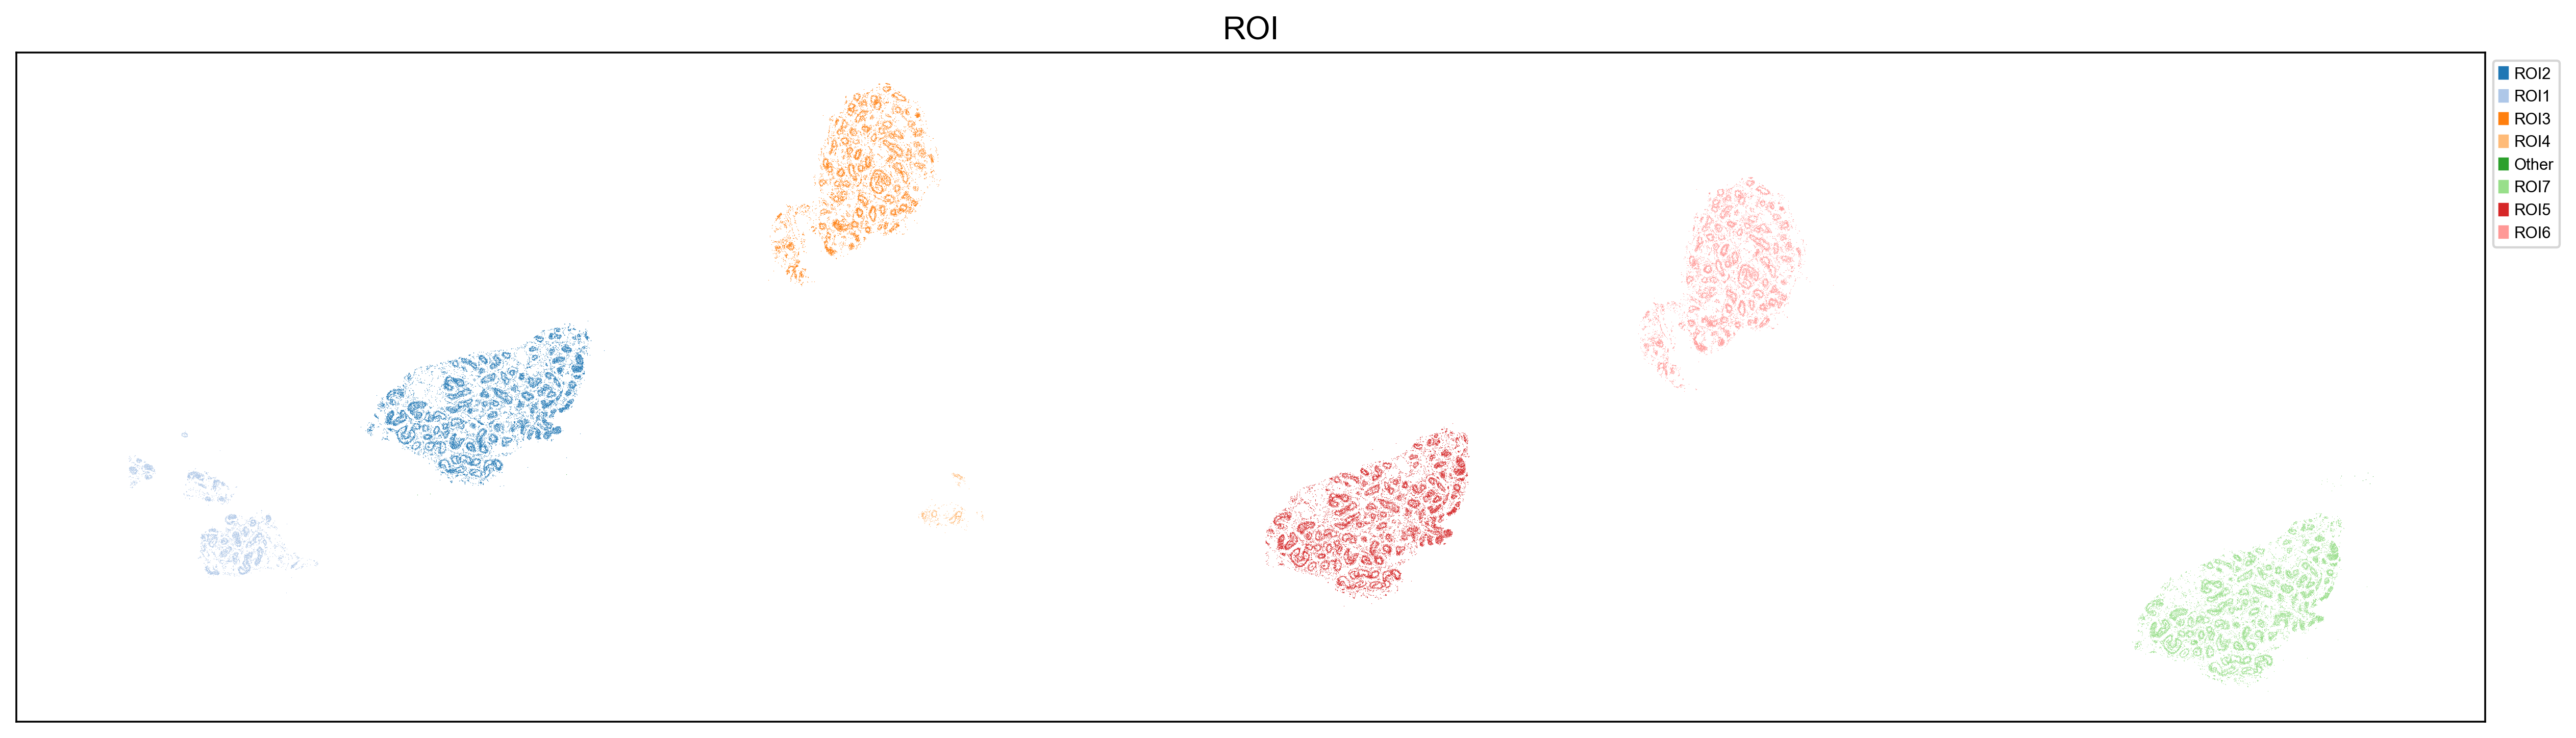

In [7]:
fig = sv.spatial_scatter_plot(
    adata,
    colorBy=ROI_KEY,
    x_coordinate="X_centroid",
    y_coordinate="Y_centroid",
    imageid="imageid",
    s=0.08,
    alpha=0.85,
    fontsize=7,
    figsize=(16, 5),
    dpi=160,
    plotLegend=True,
    saveDir=None,
)
if SAVE_OUTPUTS and fig is not None:
    fig.savefig(FIGURES_DIR / f"{SAMPLE_ID}_roi_spatial_preview.png", dpi=220, bbox_inches="tight")
plt.show()

## Level-0 Clustering Configuration

Resolution controls how many clusters are produced. If the heatmap shows clear over-splitting, lower `resolution`; if large mixed clusters remain, increase it.

In [8]:
def make_clustering_config(markers, resolution=0.6, n_neighbors=20, n_pcs=20):
    markers = keep_present(markers)
    if len(markers) < 2:
        raise ValueError("At least two markers are required for clustering.")
    n_pcs = max(1, min(n_pcs, len(markers) - 1))
    return ClusteringConfig(
        markers=markers,
        resolution=resolution,
        n_neighbors=n_neighbors,
        n_pcs=n_pcs,
        scale=True,
    )

def adapt_config_for_subset(config, n_obs):
    """Keep Scanpy PCA/neighbors settings valid for small ROI or level-1 subsets."""
    if n_obs < 3:
        raise ValueError("At least 3 cells are required for clustering.")
    max_pcs = max(1, min(len(config.markers) - 1, n_obs - 1))
    n_pcs = max(1, min(config.n_pcs, max_pcs))
    n_neighbors = max(2, min(config.n_neighbors, n_obs - 1))
    return ClusteringConfig(
        markers=list(config.markers),
        resolution=config.resolution,
        n_neighbors=n_neighbors,
        n_pcs=n_pcs,
        scale=config.scale,
    )

level0_config = make_clustering_config(
    LEVEL0_MARKERS,
    resolution=0.2,
    n_neighbors=15,
    n_pcs=20,
)

pd.Series(asdict(level0_config), name="level0_config").to_frame()

,level0_config
markers,"[FMRP, AMH, GFRA1, SOX9, CREM, MAGEA4, INSL3, ..."
resolution,0.2
n_neighbors,15
n_pcs,20
scale,True


## Run Level-0 Clustering

SpatioEv's clustering helper runs PCA, nearest neighbors, UMAP, and Leiden clustering on the marker subset. The input matrix is z-scored first so high-dynamic-range markers do not dominate PCA.

In [9]:
CLUSTER_LEVEL0_BY_ROI = True
INCLUDE_OTHER_ROI = False
MIN_CELLS_PER_ROI_FOR_CLUSTERING = 50

adata_work = adata.copy()

if SUBSAMPLE_FOR_DEVELOPMENT and adata_work.n_obs > N_CELLS_FOR_DEVELOPMENT:
    adata_work = sc.pp.subsample(
        adata_work,
        n_obs=N_CELLS_FOR_DEVELOPMENT,
        random_state=RANDOM_STATE,
        copy=True,
    )
    print(f"Development subsample: {adata_work.n_obs:,} cells")
else:
    print(f"Available QC-pass cells: {adata_work.n_obs:,}")

def run_level0_clustering_by_roi(adata_in, config):
    results = {}
    summaries = []

    if CLUSTER_LEVEL0_BY_ROI and ROI_KEY in adata_in.obs.columns:
        roi_labels = sorted(adata_in.obs[ROI_KEY].astype(str).dropna().unique())
    else:
        roi_labels = ["full_canvas"]
        adata_in = adata_in.copy()
        adata_in.obs[ROI_KEY] = "full_canvas"

    for roi in roi_labels:
        if (not INCLUDE_OTHER_ROI) and str(roi).lower() == "other":
            summaries.append({"ROI": roi, "n_cells": int((adata_in.obs[ROI_KEY].astype(str) == roi).sum()), "status": "skipped_other"})
            continue

        sub = adata_in[adata_in.obs[ROI_KEY].astype(str) == roi].copy()
        n_cells = sub.n_obs
        if n_cells < MIN_CELLS_PER_ROI_FOR_CLUSTERING:
            summaries.append({"ROI": roi, "n_cells": n_cells, "status": "skipped_too_few_cells"})
            continue

        sub = sv.zscore_normalize(sub)
        roi_config = adapt_config_for_subset(config, sub.n_obs)
        clustered = sv.cluster_cells(sub, roi_config)
        clustered.obs[ROI_KEY] = str(roi)
        clustered.obs["cluster_level0_local"] = clustered.obs["leiden"].astype(str)
        clustered.obs["cluster_level0"] = (
            clustered.obs[ROI_KEY].astype(str) + "::" + clustered.obs["cluster_level0_local"].astype(str)
        ).astype("category")

        results[str(roi)] = clustered
        summaries.append(
            {
                "ROI": roi,
                "n_cells": n_cells,
                "status": "clustered",
                "n_clusters": clustered.obs["cluster_level0"].nunique(),
                "n_neighbors": roi_config.n_neighbors,
                "n_pcs": roi_config.n_pcs,
                "resolution": roi_config.resolution,
            }
        )

    if not results:
        raise RuntimeError(
            "No ROI had enough cells to cluster. Lower MIN_CELLS_PER_ROI_FOR_CLUSTERING, "
            "set INCLUDE_OTHER_ROI=True, or check ROI assignments."
        )

    combined = ad.concat(results.values(), axis=0, join="outer", merge="same", index_unique=None)
    combined.obs["cluster_level0"] = combined.obs["cluster_level0"].astype("category")
    combined.obs[ROI_KEY] = combined.obs[ROI_KEY].astype("category")
    return combined, pd.DataFrame(summaries)

adata_lvl0, level0_roi_summary = run_level0_clustering_by_roi(adata_work, level0_config)

cluster_counts = adata_lvl0.obs["cluster_level0"].value_counts().sort_index()
display(level0_roi_summary)
display(cluster_counts.rename("n_cells").to_frame())
print(f"Level-0 clusters across clustered ROIs: {cluster_counts.shape[0]}")

Available QC-pass cells: 95,709
computing PCA
    with n_comps=33
    finished (0:00:00)
computing neighbors
    using data matrix X directly


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished (0:00:03)
computing UMAP
    finished (0:00:03)
running Leiden clustering
    finished (0:00:00)
computing PCA
    with n_comps=33
    finished (0:00:00)
computing neighbors
    using data matrix X directly
    finished (0:00:08)
computing UMAP
    finished (0:00:05)
running Leiden clustering
    finished (0:00:04)
computing PCA
    with n_comps=33
    finished (0:00:00)
computing neighbors
    using data matrix X directly
    finished (0:00:00)
computing UMAP
    finished (0:00:03)
running Leiden clustering
    finished (0:00:02)
computing PCA
    with n_comps=33
    finished (0:00:00)
computing neighbors
    using data matrix X directly
    finished (0:00:00)
computing UMAP
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
computing PCA
    with n_comps=33
    finished (0:00:00)
computing neighbors
    using data matrix X directly
    finished (0:00:00)
computing UMAP
    finished (0:00:05)
running Leiden clustering
    finished (0:00:05)
computing 

,ROI,n_cells,status,n_clusters,n_neighbors,n_pcs,resolution
0,Other,10,skipped_other,NaN,NaN,NaN,NaN
1,ROI1,5727,clustered,7.0,15.0,20.0,0.2
2,ROI2,20835,clustered,8.0,15.0,20.0,0.2
3,ROI3,13619,clustered,7.0,15.0,20.0,0.2
4,ROI4,651,clustered,3.0,15.0,20.0,0.2
5,ROI5,20585,clustered,6.0,15.0,20.0,0.2
6,ROI6,14858,clustered,5.0,15.0,20.0,0.2
7,ROI7,19424,clustered,10.0,15.0,20.0,0.2


,n_cells
cluster_level0,
ROI1::0,1809
ROI1::1,1728
ROI1::2,799
ROI1::3,700
ROI1::4,406
ROI1::5,228
ROI1::6,57
ROI2::0,7775
ROI2::1,7228


Level-0 clusters across clustered ROIs: 46


## Save Level-0 Clustering Object

This object contains the marker subset used for clustering, z-scored expression, Leiden labels, and UMAP coordinates.

In [10]:
LEVEL0_H5AD = ADATA_DIR / f"{SAMPLE_ID}_level0_clusters.h5ad"

if SAVE_OUTPUTS:
    adata_lvl0.write_h5ad(LEVEL0_H5AD, compression="gzip")
    print(f"Saved: {LEVEL0_H5AD}")
else:
    print("SAVE_OUTPUTS=False; not writing level-0 AnnData.")

Saved: /Volumes/Shihong_3/ST_Pat4_51/phenotyping/clustering_based/adata/ST_Pat4_51_level0_clusters.h5ad


## Level-0 UMAP

Use this plot together with the heatmap below. Clusters that separate strongly in UMAP but share the same marker profile may still represent spatial or intensity gradients rather than distinct cell types.

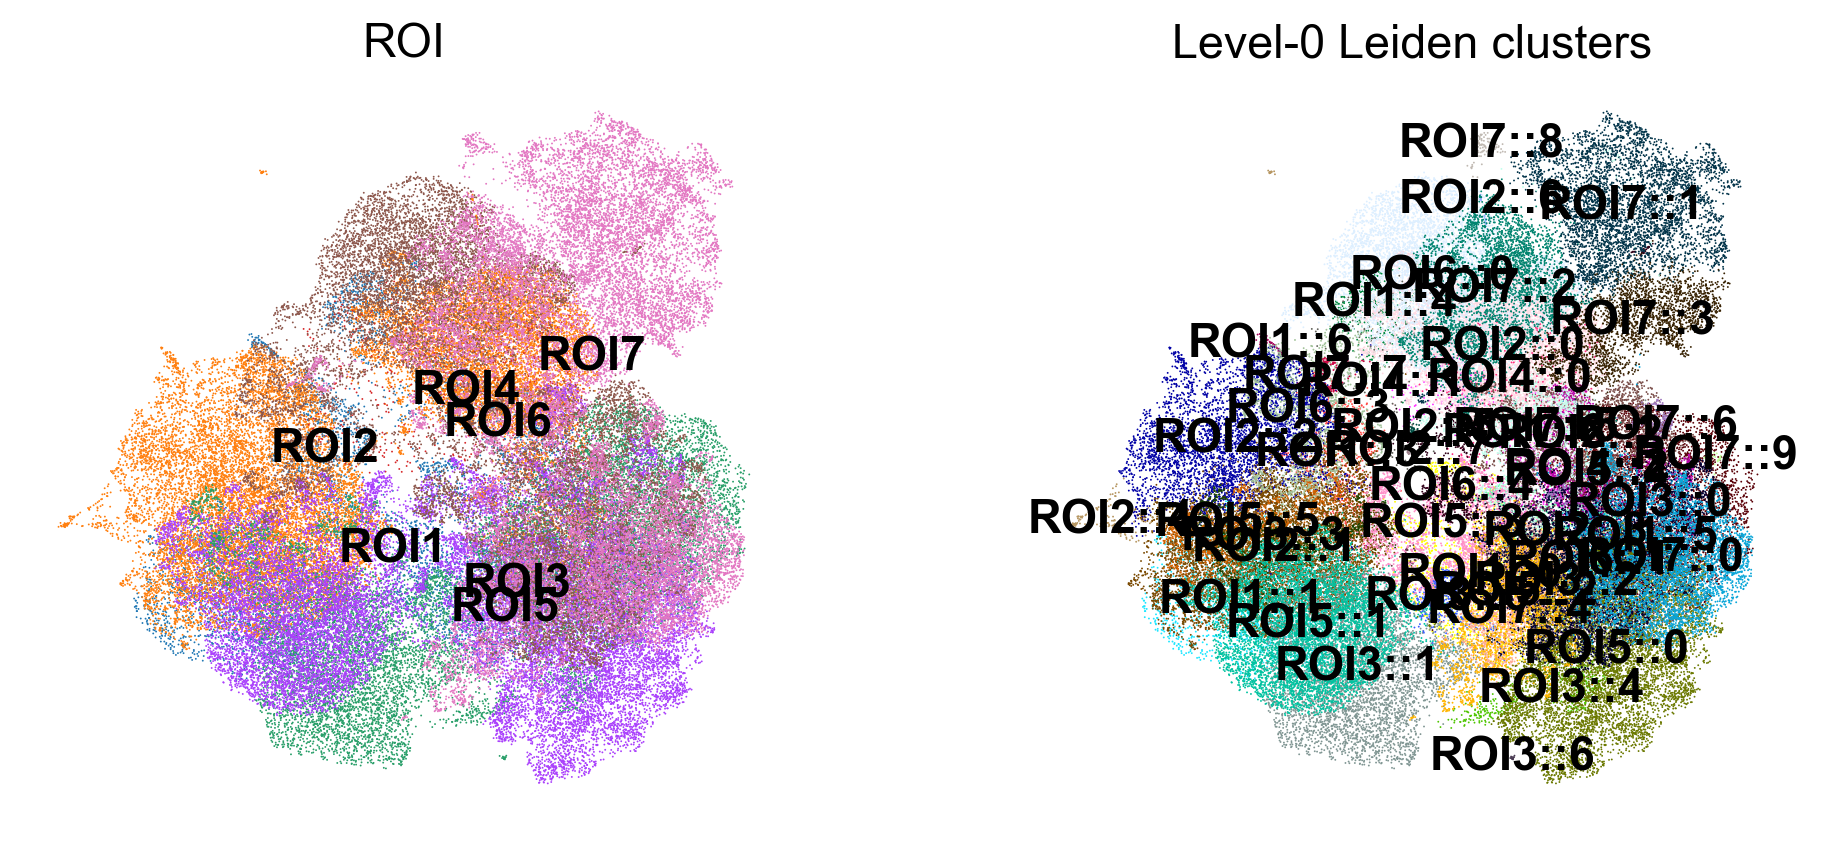

In [11]:
umap_colors = [ROI_KEY, "cluster_level0"] if ROI_KEY in adata_lvl0.obs.columns else ["cluster_level0"]
fig = sc.pl.umap(
    adata_lvl0,
    color=umap_colors,
    legend_loc="on data",
    frameon=False,
    title=["ROI", "Level-0 Leiden clusters"] if len(umap_colors) == 2 else ["Level-0 Leiden clusters"],
    show=False,
    return_fig=True,
)
if SAVE_OUTPUTS:
    fig.savefig(FIGURES_DIR / f"{SAMPLE_ID}_level0_umap_roi_and_clusters.png", dpi=200, bbox_inches="tight")
plt.show()

## Inspect Clusters Spatially

Before assigning phenotype names, inspect the level-0 clusters in spatial coordinates. This static plot is safe to run anywhere and helps catch FOV-specific artifacts, edge effects, or clusters that are mostly blank/glass-adjacent segmentation debris.

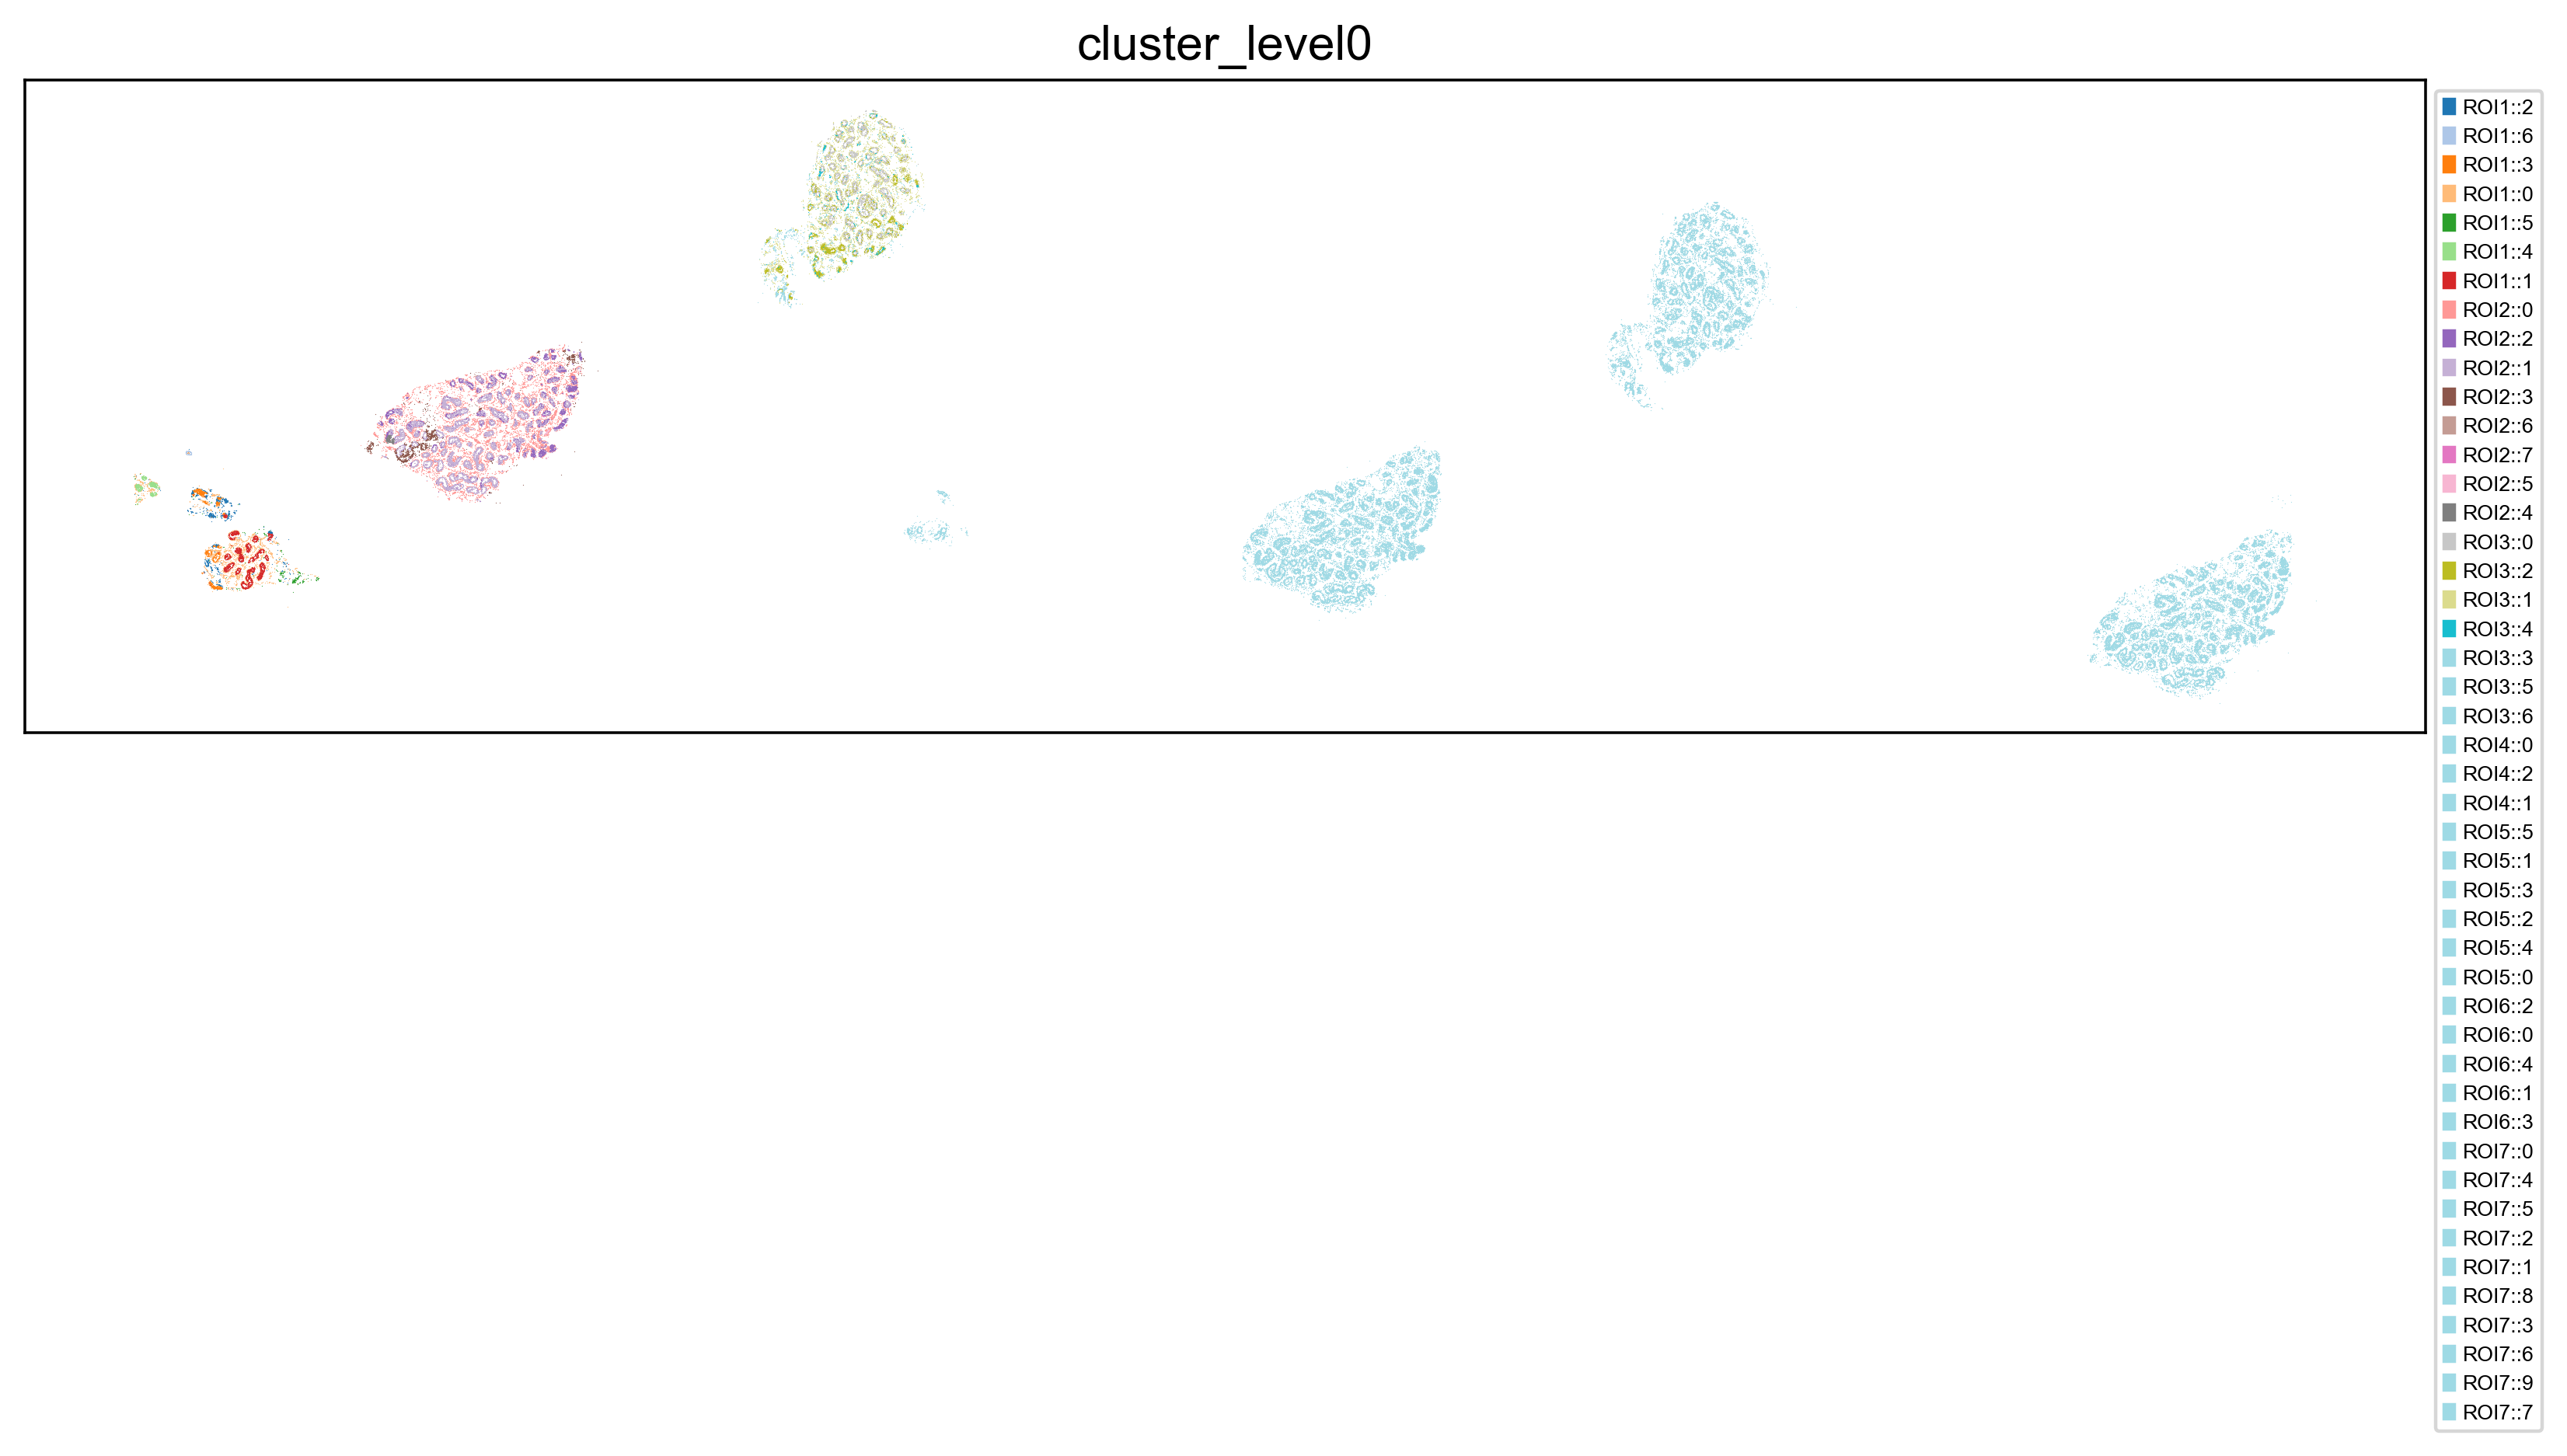

In [12]:
CLUSTER_SPATIAL_SUBSET = None  # Example: "fov0" to inspect one FOV/piece.

fig = sv.spatial_scatter_plot(
    adata_lvl0,
    colorBy="cluster_level0",
    x_coordinate="X_centroid",
    y_coordinate="Y_centroid",
    imageid="imageid",
    subset=CLUSTER_SPATIAL_SUBSET,
    s=0.08,
    alpha=0.85,
    fontsize=6,
    figsize=(16, 5),
    dpi=160,
    plotLegend=True,
    saveDir=None,
)
if SAVE_OUTPUTS and fig is not None:
    fig.savefig(FIGURES_DIR / f"{SAMPLE_ID}_level0_spatial_clusters.png", dpi=220, bbox_inches="tight")
plt.show()

## Inspect Clusters On The OME-Zarr In Napari

This cell launches Napari with selected channels from the full-canvas OME-Zarr and overlays the raw level-0 cluster point layers. By default it opens only `DNA_1` as the image background so the 433 GB OME-TIFF stays responsive; add more markers to `VIEWER_IMAGE_MARKERS` if needed.

In [13]:
RUN_CLUSTER_VIEWER = True
CLUSTER_VIEWER_MODE = "image"  # "image" overlays clusters on the full-canvas OME-Zarr; "points" skips the image.
CLUSTER_VIEWER_IMAGE_PATH = str(OME_ZARR if OME_ZARR.exists() else OME_TIFF)
VIEWER_IMAGE_MARKERS = ordered_markers  # Open all markers from markers_bs.csv; use a shorter list for faster loading.
VIEWER_SUBSET = None  # Example: "fov0" to show points from one FOV/piece on the full canvas.

if RUN_CLUSTER_VIEWER:
    if CLUSTER_VIEWER_MODE == "image":
        viewer_clusters = launch_full_canvas_overlay_viewer(
            adata_lvl0,
            image_path=CLUSTER_VIEWER_IMAGE_PATH,
            label="cluster_level0",
            channel_names=ordered_markers,
            image_markers=VIEWER_IMAGE_MARKERS,
            point_size=8,
            title=f"{SAMPLE_ID} level-0 clusters on OME-Zarr",
        )
    elif CLUSTER_VIEWER_MODE == "points":
        viewer_clusters = launch_napari_point_viewer(
            adata_lvl0,
            label="cluster_level0",
            point_size=4,
            title=f"{SAMPLE_ID} level-0 clusters",
        )
    else:
        raise ValueError("CLUSTER_VIEWER_MODE must be 'image' or 'points'.")
else:
    print("RUN_CLUSTER_VIEWER=False; set it to True to launch Napari.")

Running SCIMAP  2.3.5


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/mpl_scatter_density/__init__.py:4: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



Viewer runtime OK: napari 0.4.19.post1, scimap 2.3.5, qtpy 2.4.3
Napari OME-Zarr viewer launched: /Volumes/Shihong_3/ST_Pat4_51/background/ST_Pat4_51_backsub.ome.zarr
Loaded image markers, hidden by default: ['DNA_1', 'FMRP', 'AMH', 'GFRA1', 'SOX9', 'CREM', 'MAGEA4', 'INSL3', 'KRT18', 'PIWIL4', 'NaATPase', 'UTF1', 'panCadherin', 'KI67', 'CLDN11', 'DMRT1', 'CX43', 'STAR', 'CYP17A1', 'SYCP3', 'CYP11A1', 'PCNA', 'CD45', 'CD68', 'NF2F2', 'CD31', 'UTF1_1', 'Vimentin', 'VIMENTIN_1', 'CX43_1', 'Acrosin', 'MYH11', 'SMA', 'CD8', 'DNA_25', 'CLDN11_2']
Loaded point layers, hidden by default for cluster_level0: 46
If the window is not in front, check the Dock or Window menu.


## Annotate Level-0 Clusters Interactively

This is the only level-0 labelling step. It prompts for one label per cluster and saves the resulting annotation table. Press Enter to keep the current cluster ID.

In [14]:
ANNOTATE_LEVEL0_INTERACTIVELY = True

DRAFT_REVIEW_CSV = TABLES_DIR / f"{SAMPLE_ID}_level0_cluster_annotation_review.csv"
REVIEWED_ANNOTATION_CSV = TABLES_DIR / f"{SAMPLE_ID}_level0_cluster_annotation_reviewed.csv"

def _cluster_sort_key(value):
    text = str(value)
    return (0, int(text)) if text.isdigit() else (1, text)

def make_annotation_table_from_clusters(adata_obj, cluster_key):
    table = (
        adata_obj.obs[cluster_key]
        .astype(str)
        .value_counts()
        .sort_index()
        .rename("n_cells")
        .to_frame()
    )
    table["annotation"] = table.index.astype(str)
    table["review_note"] = ""
    table.index.name = "cluster"
    return table

def annotate_clusters_interactively(
    adata_obj,
    review_table=None,
    cluster_key="cluster_level0",
    new_key="annotation_level0",
):
    if review_table is None or review_table.empty:
        review = make_annotation_table_from_clusters(adata_obj, cluster_key)
    else:
        review = review_table.copy()
        review.index = review.index.astype(str)

    clusters = sorted(adata_obj.obs[cluster_key].astype(str).unique(), key=_cluster_sort_key)
    mapping = {}

    print("Enter one annotation per cluster. Press Enter to keep the current cluster ID/value.\n")
    for cluster in clusters:
        row = review.loc[cluster] if cluster in review.index else pd.Series(dtype=object)
        current = str(row.get("annotation", cluster))
        n_cells = row.get("n_cells", int((adata_obj.obs[cluster_key].astype(str) == cluster).sum()))
        label = input(f"Cluster {cluster} | n={n_cells} | current={current}: ").strip()
        mapping[cluster] = label if label else current

    annotated = adata_obj.copy()
    annotated.obs[new_key] = (
        annotated.obs[cluster_key]
        .astype(str)
        .map(mapping)
        .fillna("unassigned")
        .astype("category")
    )

    updated_table = review.copy()
    mapped_annotations = pd.Series(updated_table.index, index=updated_table.index).map(mapping)
    updated_table["annotation"] = mapped_annotations.fillna(updated_table["annotation"].astype(str))
    updated_table["review_note"] = updated_table.get("review_note", "")
    return annotated, mapping, updated_table

cluster_annotation_table = make_annotation_table_from_clusters(adata_lvl0, "cluster_level0")

if ANNOTATE_LEVEL0_INTERACTIVELY:
    adata_lvl0, interactive_mapping, cluster_annotation_table = annotate_clusters_interactively(
        adata_lvl0,
        cluster_annotation_table,
        cluster_key="cluster_level0",
        new_key="annotation_level0",
    )

    if SAVE_OUTPUTS:
        cluster_annotation_table.to_csv(REVIEWED_ANNOTATION_CSV)
        print(f"Saved interactive annotations: {REVIEWED_ANNOTATION_CSV}")
else:
    print("Interactive annotation skipped.")
    if SAVE_OUTPUTS:
        cluster_annotation_table.to_csv(DRAFT_REVIEW_CSV)
        print(f"Saved unlabeled cluster table: {DRAFT_REVIEW_CSV}")

display(cluster_annotation_table)

Enter one annotation per cluster. Press Enter to keep the current cluster ID/value.

Saved interactive annotations: /Volumes/Shihong_3/ST_Pat4_51/phenotyping/clustering_based/tables/ST_Pat4_51_level0_cluster_annotation_reviewed.csv


,n_cells,annotation,review_note
cluster,,,
ROI1::0,1809,s,
ROI1::1,1728,t,
ROI1::2,799,t,
ROI1::3,700,t,
ROI1::4,406,t,
ROI1::5,228,t,
ROI1::6,57,t,
ROI2::0,7775,s,
ROI2::1,7228,t,


## Apply Reviewed Or Manual Level-0 Annotations

If `ST_Pat4_51_level0_cluster_annotation_reviewed.csv` exists, the notebook uses its `annotation` column. Otherwise it uses the draft table created above.

In [15]:
annotation_source = None

if REVIEWED_ANNOTATION_CSV.exists():
    annotation_table_path = REVIEWED_ANNOTATION_CSV
    annotation_table = pd.read_csv(annotation_table_path, dtype={"cluster": str})
    annotation_source = annotation_table_path
elif DRAFT_REVIEW_CSV.exists():
    annotation_table_path = DRAFT_REVIEW_CSV
    annotation_table = pd.read_csv(annotation_table_path, dtype={"cluster": str})
    annotation_source = annotation_table_path
else:
    annotation_table = cluster_annotation_table.reset_index().copy()
    annotation_source = "in-memory manual review table"

if "cluster" not in annotation_table.columns:
    annotation_table = annotation_table.rename(columns={annotation_table.columns[0]: "cluster"})
if "annotation" not in annotation_table.columns:
    raise ValueError("Expected an 'annotation' column in the cluster annotation table.")

cluster_to_annotation = dict(
    zip(annotation_table["cluster"].astype(str), annotation_table["annotation"].astype(str))
)

adata_lvl0.obs["annotation_level0"] = (
    adata_lvl0.obs["cluster_level0"]
    .astype(str)
    .map(cluster_to_annotation)
    .fillna("unassigned")
    .astype("category")
)

print(f"Loaded annotations from: {annotation_source}")
display(adata_lvl0.obs["annotation_level0"].value_counts().rename("n_cells").to_frame())

Loaded annotations from: /Volumes/Shihong_3/ST_Pat4_51/phenotyping/clustering_based/tables/ST_Pat4_51_level0_cluster_annotation_reviewed.csv


,n_cells
annotation_level0,
t,59909
s,35689
a,101


## View Annotated Clusters On The OME-Zarr In Napari

After annotations are applied, this cell overlays phenotype labels on the selected OME-Zarr background channels.

In [16]:
RUN_ANNOTATED_CLUSTER_VIEWER = True
ANNOTATED_VIEWER_MODE = "image"  # "image" overlays annotations on the full-canvas OME-Zarr; "points" skips the image.
ANNOTATED_VIEWER_IMAGE_MARKERS = VIEWER_IMAGE_MARKERS

if RUN_ANNOTATED_CLUSTER_VIEWER:
    if ANNOTATED_VIEWER_MODE == "image":
        viewer_annotations = launch_full_canvas_overlay_viewer(
            adata_lvl0,
            image_path=CLUSTER_VIEWER_IMAGE_PATH,
            label="annotation_level0",
            channel_names=ordered_markers,
            image_markers=ANNOTATED_VIEWER_IMAGE_MARKERS,
            point_size=8,
            title=f"{SAMPLE_ID} level-0 annotations on OME-Zarr",
        )
    elif ANNOTATED_VIEWER_MODE == "points":
        viewer_annotations = launch_napari_point_viewer(
            adata_lvl0,
            label="annotation_level0",
            point_size=4,
            title=f"{SAMPLE_ID} level-0 annotations",
        )
    else:
        raise ValueError("ANNOTATED_VIEWER_MODE must be 'image' or 'points'.")
else:
    print("RUN_ANNOTATED_CLUSTER_VIEWER=False; set it to True to launch Napari.")

Viewer runtime OK: napari 0.4.19.post1, scimap 2.3.5, qtpy 2.4.3
Napari OME-Zarr viewer launched: /Volumes/Shihong_3/ST_Pat4_51/background/ST_Pat4_51_backsub.ome.zarr
Loaded image markers, hidden by default: ['DNA_1', 'FMRP', 'AMH', 'GFRA1', 'SOX9', 'CREM', 'MAGEA4', 'INSL3', 'KRT18', 'PIWIL4', 'NaATPase', 'UTF1', 'panCadherin', 'KI67', 'CLDN11', 'DMRT1', 'CX43', 'STAR', 'CYP17A1', 'SYCP3', 'CYP11A1', 'PCNA', 'CD45', 'CD68', 'NF2F2', 'CD31', 'UTF1_1', 'Vimentin', 'VIMENTIN_1', 'CX43_1', 'Acrosin', 'MYH11', 'SMA', 'CD8', 'DNA_25', 'CLDN11_2']
Loaded point layers, hidden by default for annotation_level0: 3
If the window is not in front, check the Dock or Window menu.


## View Annotated Clusters On UMAP

This is the quick check that cluster-to-phenotype mapping has been applied as expected.

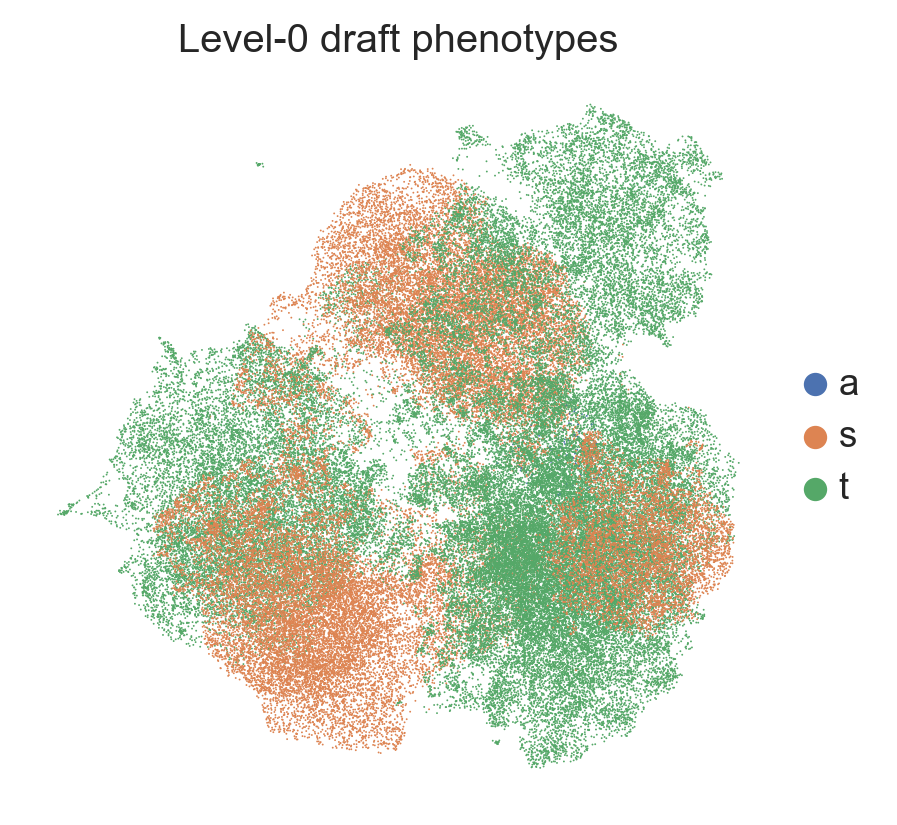

In [17]:
fig = sc.pl.umap(
    adata_lvl0,
    color="annotation_level0",
    frameon=False,
    title="Level-0 draft phenotypes",
    show=False,
    return_fig=True,
)
if SAVE_OUTPUTS:
    fig.savefig(FIGURES_DIR / f"{SAMPLE_ID}_level0_umap_annotations.png", dpi=200, bbox_inches="tight")
plt.show()

## View Annotated Clusters Spatially

This overlays the phenotype labels on the full stitched canvas coordinates. Use it to catch obvious mislabels, FOV-specific artifacts, or clusters driven by segmentation/image edge effects.

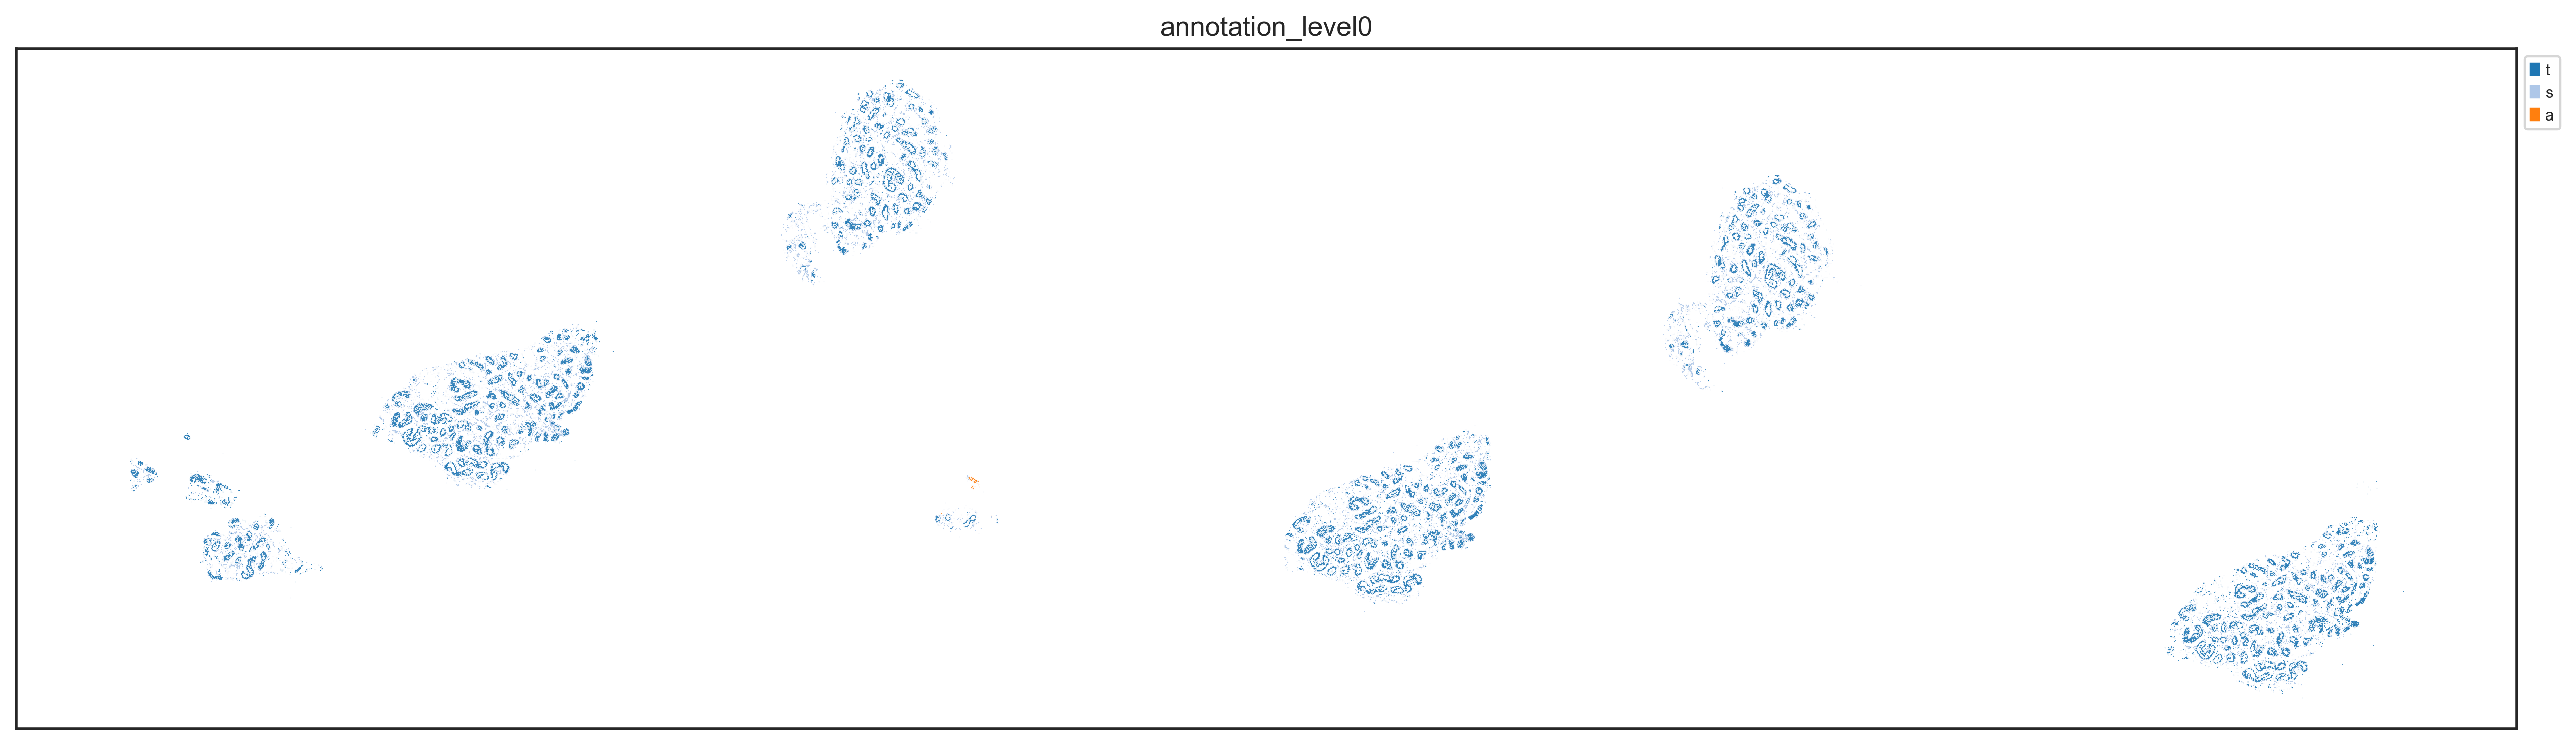

In [18]:
SPATIAL_SUBSET = None  # Example: "fov0" to plot one FOV/piece only.

fig = sv.spatial_scatter_plot(
    adata_lvl0,
    colorBy="annotation_level0",
    x_coordinate="X_centroid",
    y_coordinate="Y_centroid",
    imageid="imageid",
    subset=SPATIAL_SUBSET,
    s=0.08,
    alpha=0.85,
    fontsize=7,
    figsize=(16, 5),
    dpi=160,
    plotLegend=True,
    saveDir=None,
)
if SAVE_OUTPUTS and fig is not None:
    fig.savefig(FIGURES_DIR / f"{SAMPLE_ID}_level0_spatial_annotations.png", dpi=220, bbox_inches="tight")
plt.show()

## Save Phenotype Assignments

This writes labels back onto a copy of the QC-filtered AnnData. If development subsampling is on, cells outside the subsample are marked as `not_clustered`.

In [19]:
adata_pheno = adata.copy()
adata_pheno.obs["cluster_level0"] = "not_clustered"
adata_pheno.obs["annotation_level0"] = "not_clustered"

adata_pheno.obs.loc[adata_lvl0.obs_names, "cluster_level0"] = adata_lvl0.obs["cluster_level0"].astype(str)
adata_pheno.obs.loc[adata_lvl0.obs_names, "annotation_level0"] = adata_lvl0.obs["annotation_level0"].astype(str)

adata_pheno.obs["cluster_level0"] = adata_pheno.obs["cluster_level0"].astype("category")
adata_pheno.obs["annotation_level0"] = adata_pheno.obs["annotation_level0"].astype("category")

PHENOTYPED_H5AD = ADATA_DIR / f"{SAMPLE_ID}_phenotyping_level0.h5ad"
ASSIGNMENTS_CSV = TABLES_DIR / f"{SAMPLE_ID}_level0_phenotype_assignments.csv"

assignment_cols = [
    "imageid",
    ROI_KEY,
    "X_centroid",
    "Y_centroid",
    "cluster_level0",
    "annotation_level0",
]
assignment_cols = [col for col in assignment_cols if col in adata_pheno.obs.columns]

if SAVE_OUTPUTS:
    adata_pheno.write_h5ad(PHENOTYPED_H5AD, compression="gzip")
    adata_pheno.obs[assignment_cols].to_csv(ASSIGNMENTS_CSV)
    print(f"Saved: {PHENOTYPED_H5AD}")
    print(f"Saved: {ASSIGNMENTS_CSV}")

display(adata_pheno.obs["annotation_level0"].value_counts().rename("n_cells").to_frame())

Saved: /Volumes/Shihong_3/ST_Pat4_51/phenotyping/clustering_based/adata/ST_Pat4_51_phenotyping_level0.h5ad
Saved: /Volumes/Shihong_3/ST_Pat4_51/phenotyping/clustering_based/tables/ST_Pat4_51_level0_phenotype_assignments.csv


,n_cells
annotation_level0,
t,59909
s,35689
a,101
not_clustered,10


## Level-1 Clustering Configuration

Level 1 refines selected level-0 annotations or clusters. By default it is ROI-aware: for each selected target such as `t`, the notebook reclusters that target independently inside each ROI. Level-1 cluster IDs are named like `ROI::parent::subcluster`.

Set `LEVEL1_SOURCE_KEY = "annotation_level0"` to refine broad labels such as `t` or `s`. Set `LEVEL1_SOURCE_KEY = "cluster_level0"` if you want to refine exact level-0 clusters.

In [20]:
RUN_LEVEL1_CLUSTERING = True

# Refine broad level-0 annotations.
# Current level-0 labels:
#   t = tubule
#   s = stroma
#   a = artifact
LEVEL1_SOURCE_KEY = "annotation_level0"

# Start with tubule only. Add "s" later if you also want to refine stroma.
# Skip "a" unless you want artifact subtypes.
LEVEL1_TARGETS = ["t"]

MIN_CELLS_PER_LEVEL1_TARGET = 50

CLUSTER_LEVEL1_BY_ROI = True
LEVEL1_ROI_KEY = ROI_KEY
INCLUDE_OTHER_ROI_LEVEL1 = False


LEVEL1_MARKERS_BY_TARGET = {
    # Tubule refinement: separates Sertoli/germ/proliferating/spermatogenic states.
    "t": [
        "SOX9", "MAGEA4", "CREM", "SYCP3", "Acrosin"
    ],

    # Stroma refinement: useful if you later set LEVEL1_TARGETS = ["t", "s"].
    "s": [
        "Vimentin", "SMA", "MYH11", "CYP17A1"
    ],
}

LEVEL1_DEFAULT_MARKERS = LEVEL0_MARKERS

LEVEL1_RESOLUTION_BY_TARGET = {
    "t": 0.5,
    "s": 0.5,
}

if LEVEL1_SOURCE_KEY not in adata_pheno.obs.columns:
    raise ValueError(f"{LEVEL1_SOURCE_KEY!r} is not in adata_pheno.obs")

available_level1_targets = (
    adata_pheno.obs[LEVEL1_SOURCE_KEY]
    .astype(str)
    .value_counts()
    .rename("n_cells")
    .to_frame()
)
display(available_level1_targets)

if CLUSTER_LEVEL1_BY_ROI and LEVEL1_ROI_KEY in adata_pheno.obs.columns:
    level1_roi_target_counts = pd.crosstab(
        adata_pheno.obs[LEVEL1_ROI_KEY].astype(str),
        adata_pheno.obs[LEVEL1_SOURCE_KEY].astype(str),
    )
    display(level1_roi_target_counts)

missing_targets = [
    target for target in LEVEL1_TARGETS
    if target not in available_level1_targets.index
]
if missing_targets:
    print(f"These LEVEL1_TARGETS were not found in {LEVEL1_SOURCE_KEY}: {missing_targets}")

if not LEVEL1_TARGETS:
    print("LEVEL1_TARGETS is empty. Fill it, then set RUN_LEVEL1_CLUSTERING=True.")

,n_cells
annotation_level0,
t,59909
s,35689
a,101
not_clustered,10


annotation_level0,a,not_clustered,s,t
ROI,,,,
Other,0,10,0,0
ROI1,0,0,1809,3918
ROI2,0,0,7802,13033
ROI3,0,0,6151,7468
ROI4,101,0,298,252
ROI5,0,0,7241,13344
ROI6,0,0,7070,7788
ROI7,0,0,5318,14106


## Run Level-1 Clustering

Each selected level-0 target is subset from the full phenotyped AnnData, z-scored independently, clustered independently, and labelled as `parent::subcluster`.

In [21]:
def markers_for_level1_target(target):
    if target in LEVEL1_MARKERS_BY_TARGET:
        return keep_present(LEVEL1_MARKERS_BY_TARGET[target])
    # If target is an exact ROI::cluster label, fall back to all non-DNA level-0 markers.
    return keep_present(LEVEL1_DEFAULT_MARKERS)

def make_level1_group_label(target, roi):
    if CLUSTER_LEVEL1_BY_ROI:
        return f"{roi}::{target}"
    return str(target)

def run_level1_clustering(parent_adata, source_key, targets):
    results = {}
    summaries = []

    for target in targets:
        target_data = parent_adata[parent_adata.obs[source_key].astype(str) == str(target)].copy()
        n_target_cells = target_data.n_obs
        if n_target_cells == 0:
            summaries.append({"target": target, "ROI": None, "n_cells": 0, "status": "skipped_missing_target"})
            continue

        if CLUSTER_LEVEL1_BY_ROI and LEVEL1_ROI_KEY in target_data.obs.columns:
            roi_labels = sorted(target_data.obs[LEVEL1_ROI_KEY].astype(str).dropna().unique())
        else:
            roi_labels = ["all_rois"]
            target_data.obs[LEVEL1_ROI_KEY] = "all_rois"

        for roi in roi_labels:
            if (not INCLUDE_OTHER_ROI_LEVEL1) and str(roi).lower() == "other":
                summaries.append({"target": target, "ROI": roi, "n_cells": int((target_data.obs[LEVEL1_ROI_KEY].astype(str) == roi).sum()), "status": "skipped_other"})
                continue

            sub = target_data[target_data.obs[LEVEL1_ROI_KEY].astype(str) == str(roi)].copy()
            n_cells = sub.n_obs
            if n_cells < MIN_CELLS_PER_LEVEL1_TARGET:
                summaries.append({"target": target, "ROI": roi, "n_cells": n_cells, "status": "skipped_too_few_cells"})
                continue

            markers = markers_for_level1_target(str(target))
            resolution = LEVEL1_RESOLUTION_BY_TARGET.get(str(target), 0.5)
            base_config = make_clustering_config(markers, resolution=resolution, n_neighbors=20, n_pcs=20)
            target_config = adapt_config_for_subset(base_config, sub.n_obs)

            sub = sv.zscore_normalize(sub)
            clustered = sv.cluster_cells(sub, target_config)
            group_label = make_level1_group_label(str(target), str(roi))

            clustered.obs["level1_parent_key"] = source_key
            clustered.obs["level1_parent"] = str(target)
            clustered.obs["level1_roi"] = str(roi)
            clustered.obs["level1_group"] = group_label
            clustered.obs["cluster_level1_local"] = clustered.obs["leiden"].astype(str)
            clustered.obs["cluster_level1"] = (
                clustered.obs["level1_group"].astype(str) + "::" + clustered.obs["cluster_level1_local"].astype(str)
            ).astype("category")

            results[group_label] = clustered
            summaries.append(
                {
                    "target": target,
                    "ROI": roi,
                    "level1_group": group_label,
                    "n_cells": n_cells,
                    "status": "clustered",
                    "n_clusters": clustered.obs["cluster_level1"].nunique(),
                    "markers": ", ".join(markers),
                    "n_neighbors": target_config.n_neighbors,
                    "n_pcs": target_config.n_pcs,
                    "resolution": target_config.resolution,
                }
            )

    summary = pd.DataFrame(summaries)
    if not results:
        return None, results, summary

    combined = ad.concat(results.values(), axis=0, join="outer", merge="same", index_unique=None)
    combined.obs["cluster_level1"] = combined.obs["cluster_level1"].astype("category")
    combined.obs["level1_group"] = combined.obs["level1_group"].astype("category")
    combined.obs["level1_roi"] = combined.obs["level1_roi"].astype("category")
    return combined, results, summary

if RUN_LEVEL1_CLUSTERING and LEVEL1_TARGETS:
    adata_lvl1, level1_results, level1_summary = run_level1_clustering(
        adata_pheno,
        source_key=LEVEL1_SOURCE_KEY,
        targets=LEVEL1_TARGETS,
    )
    display(level1_summary)

    if adata_lvl1 is not None and SAVE_OUTPUTS:
        LEVEL1_H5AD = ADATA_DIR / f"{SAMPLE_ID}_level1_clusters.h5ad"
        adata_lvl1.write_h5ad(LEVEL1_H5AD, compression="gzip")
        print(f"Saved: {LEVEL1_H5AD}")
else:
    adata_lvl1 = None
    level1_results = {}
    level1_summary = pd.DataFrame()
    print("Level-1 clustering skipped. Set RUN_LEVEL1_CLUSTERING=True and provide LEVEL1_TARGETS.")

computing PCA
    with n_comps=4
    finished (0:00:00)
computing neighbors
    using data matrix X directly
    finished (0:00:00)
computing UMAP
    finished (0:00:02)
running Leiden clustering
    finished (0:00:00)
computing PCA
    with n_comps=4
    finished (0:00:00)
computing neighbors
    using data matrix X directly
    finished (0:00:01)
computing UMAP
    finished (0:00:03)
running Leiden clustering
    finished (0:00:02)
computing PCA
    with n_comps=4
    finished (0:00:00)
computing neighbors
    using data matrix X directly
    finished (0:00:00)
computing UMAP
    finished (0:00:04)
running Leiden clustering
    finished (0:00:02)
computing PCA
    with n_comps=4
    finished (0:00:00)
computing neighbors
    using data matrix X directly
    finished (0:00:00)
computing UMAP
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
computing PCA
    with n_comps=4
    finished (0:00:00)
computing neighbors
    using data matrix X directly
    finished (0

,target,ROI,level1_group,n_cells,status,n_clusters,markers,n_neighbors,n_pcs,resolution
0,t,ROI1,ROI1::t,3918,clustered,13,"SOX9, MAGEA4, CREM, SYCP3, Acrosin",20,4,0.5
1,t,ROI2,ROI2::t,13033,clustered,12,"SOX9, MAGEA4, CREM, SYCP3, Acrosin",20,4,0.5
2,t,ROI3,ROI3::t,7468,clustered,10,"SOX9, MAGEA4, CREM, SYCP3, Acrosin",20,4,0.5
3,t,ROI4,ROI4::t,252,clustered,7,"SOX9, MAGEA4, CREM, SYCP3, Acrosin",20,4,0.5
4,t,ROI5,ROI5::t,13344,clustered,11,"SOX9, MAGEA4, CREM, SYCP3, Acrosin",20,4,0.5
5,t,ROI6,ROI6::t,7788,clustered,11,"SOX9, MAGEA4, CREM, SYCP3, Acrosin",20,4,0.5
6,t,ROI7,ROI7::t,14106,clustered,13,"SOX9, MAGEA4, CREM, SYCP3, Acrosin",20,4,0.5


Saved: /Volumes/Shihong_3/ST_Pat4_51/phenotyping/clustering_based/adata/ST_Pat4_51_level1_clusters.h5ad


## Level-1 UMAPs

These UMAPs show the raw level-1 clusters for each ROI-aware refinement group before annotation.

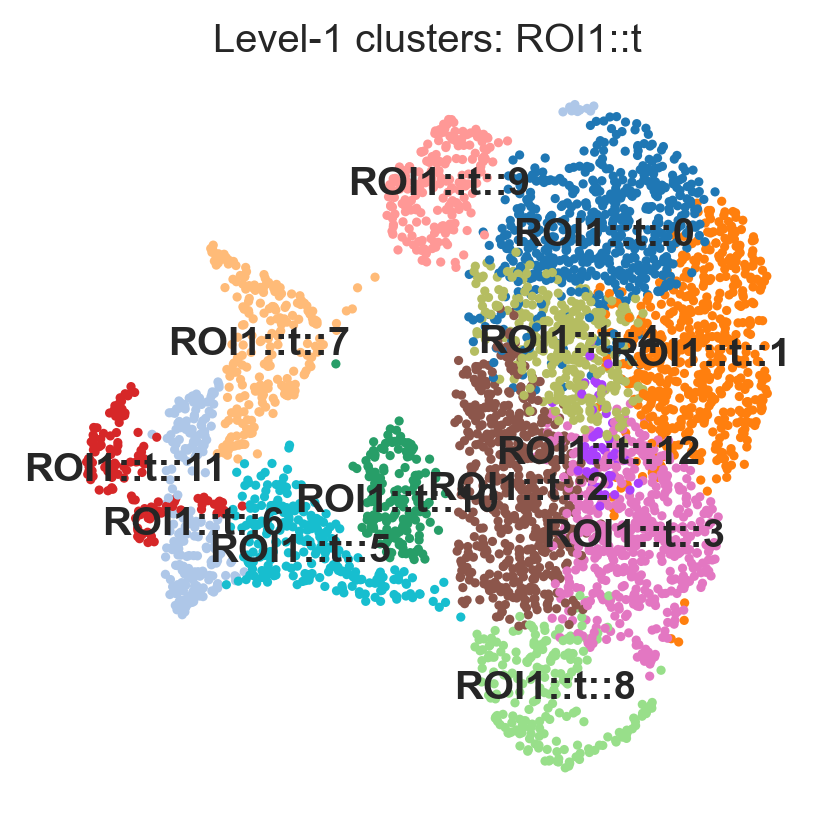

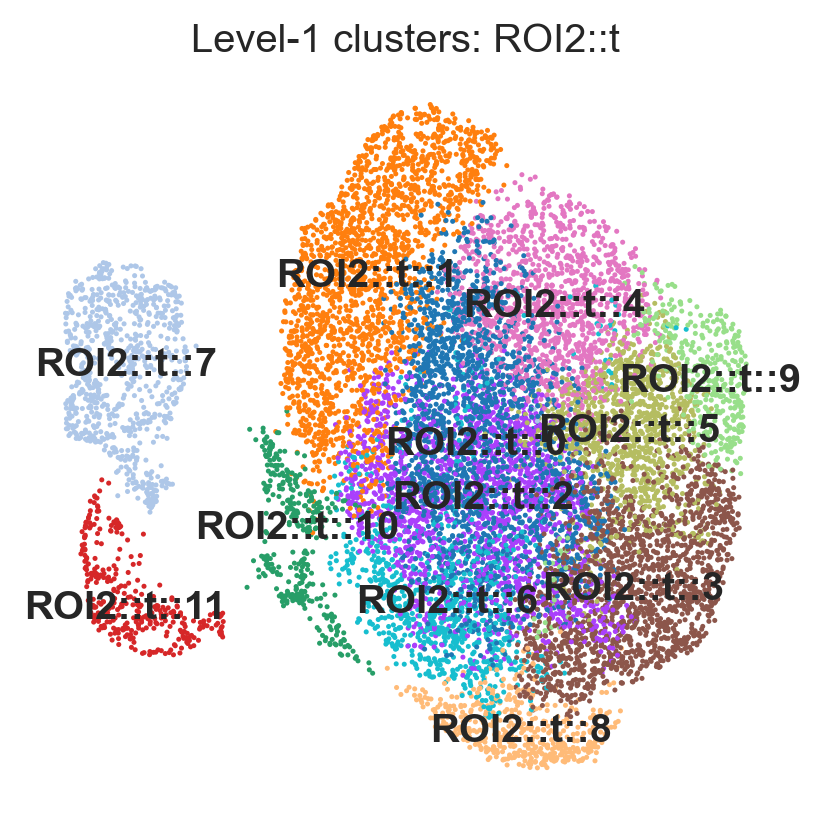

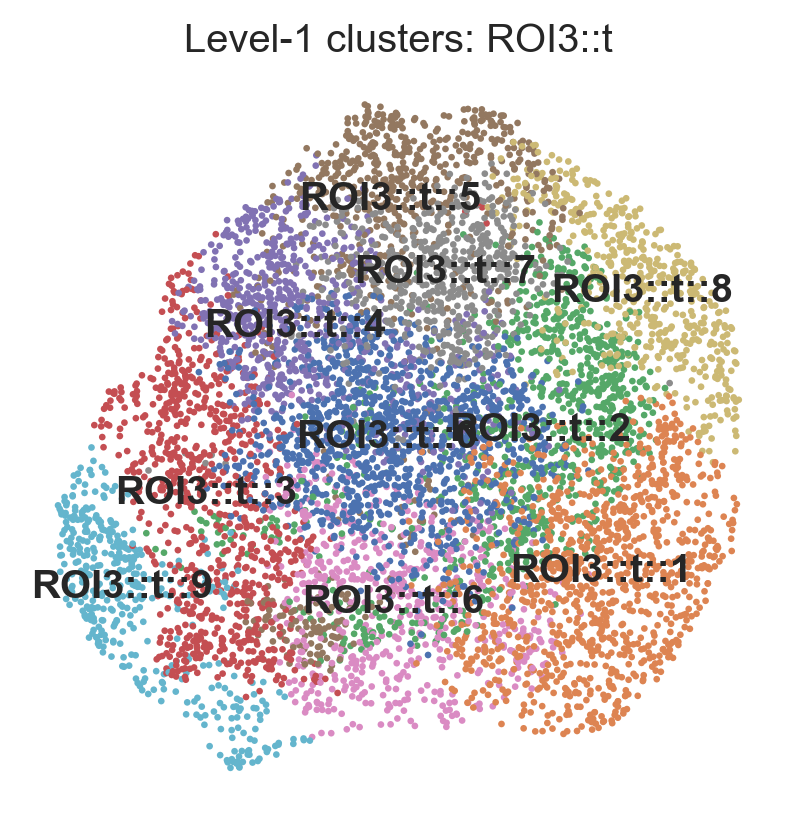

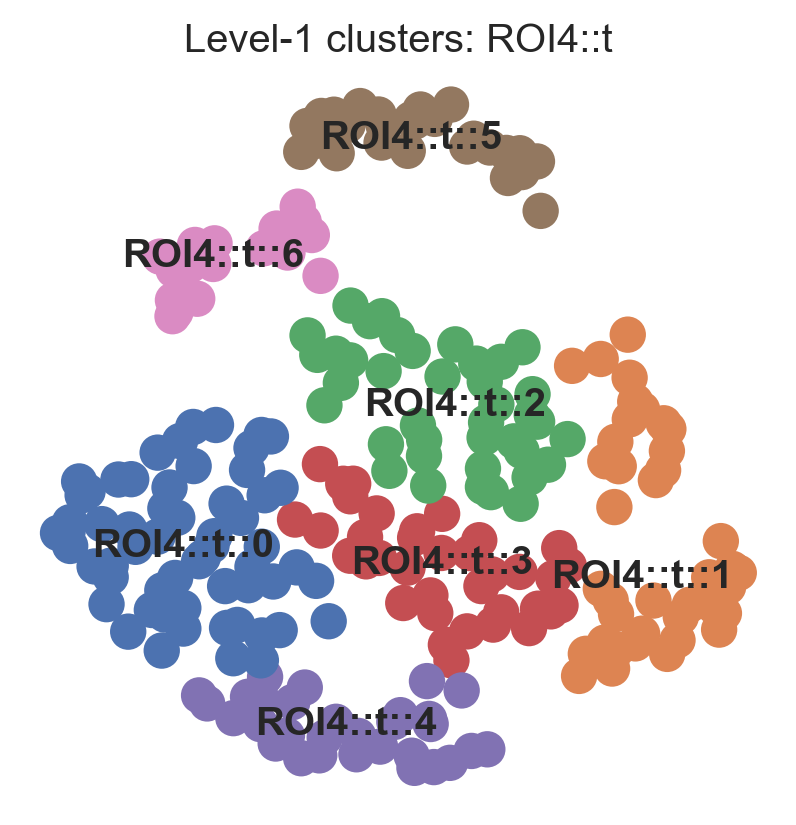

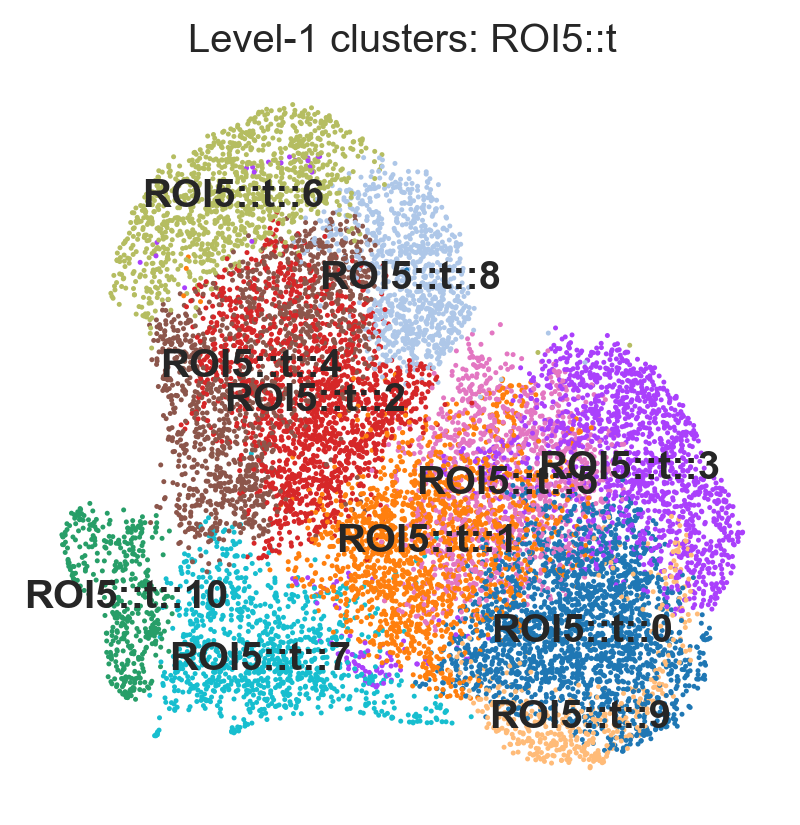

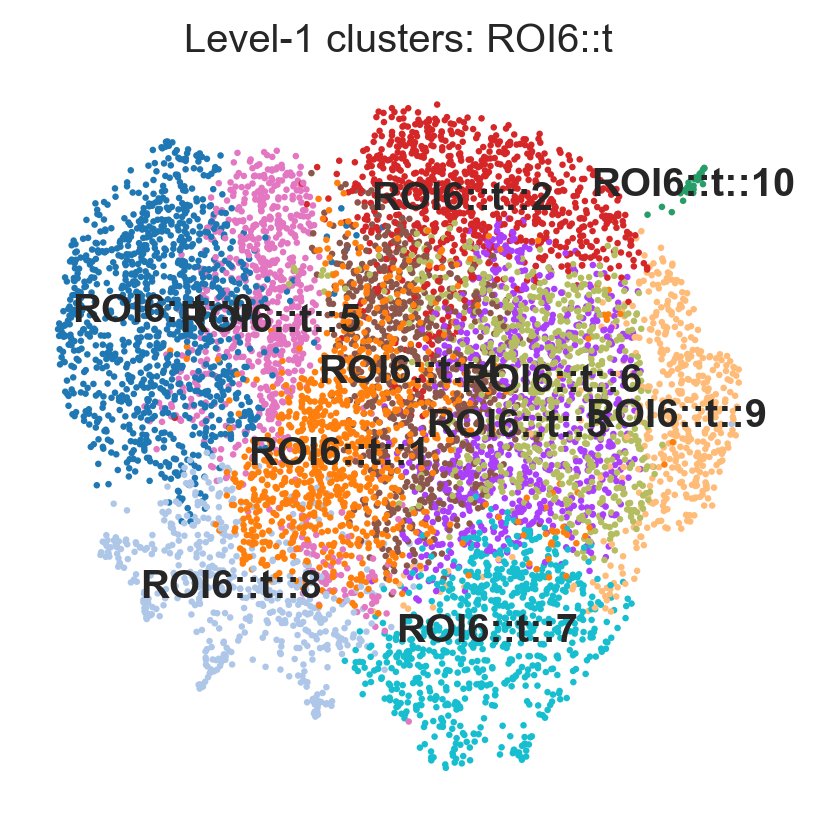

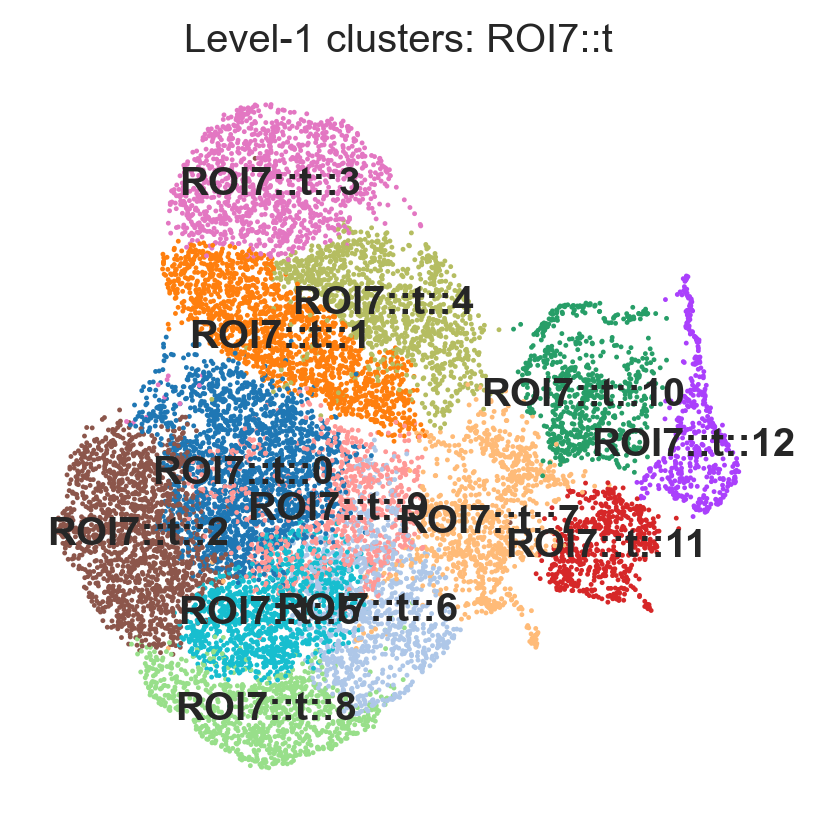

In [22]:
if adata_lvl1 is not None:
    for target, sub in level1_results.items():
        fig = sc.pl.umap(
            sub,
            color="cluster_level1",
            legend_loc="on data",
            frameon=False,
            title=f"Level-1 clusters: {target}",
            show=False,
            return_fig=True,
        )
        if SAVE_OUTPUTS:
            safe_target = str(target).replace("/", "_").replace("::", "__")
            fig.savefig(FIGURES_DIR / f"{SAMPLE_ID}_level1_umap_{safe_target}.png", dpi=200, bbox_inches="tight")
        plt.show()
else:
    print("No level-1 object available yet.")

## View Level-1 Clusters On The OME-Zarr In Napari

Before naming level-1 clusters, overlay the raw `cluster_level1` labels on the OME-Zarr. This is the level-1 equivalent of the level-0 image review step.

In [23]:
RUN_LEVEL1_CLUSTER_VIEWER = True

if adata_lvl1 is not None and RUN_LEVEL1_CLUSTER_VIEWER:
    viewer_level1_clusters = launch_full_canvas_overlay_viewer(
        adata_lvl1,
        image_path=CLUSTER_VIEWER_IMAGE_PATH,
        label="cluster_level1",
        channel_names=ordered_markers,
        image_markers=VIEWER_IMAGE_MARKERS,
        point_size=8,
        title=f"{SAMPLE_ID} level-1 clusters on OME-Zarr",
    )
elif adata_lvl1 is None:
    print("No level-1 object available yet.")
else:
    print("RUN_LEVEL1_CLUSTER_VIEWER=False; set it to True to inspect level-1 clusters on the image.")

Viewer runtime OK: napari 0.4.19.post1, scimap 2.3.5, qtpy 2.4.3
Napari OME-Zarr viewer launched: /Volumes/Shihong_3/ST_Pat4_51/background/ST_Pat4_51_backsub.ome.zarr
Loaded image markers, hidden by default: ['DNA_1', 'FMRP', 'AMH', 'GFRA1', 'SOX9', 'CREM', 'MAGEA4', 'INSL3', 'KRT18', 'PIWIL4', 'NaATPase', 'UTF1', 'panCadherin', 'KI67', 'CLDN11', 'DMRT1', 'CX43', 'STAR', 'CYP17A1', 'SYCP3', 'CYP11A1', 'PCNA', 'CD45', 'CD68', 'NF2F2', 'CD31', 'UTF1_1', 'Vimentin', 'VIMENTIN_1', 'CX43_1', 'Acrosin', 'MYH11', 'SMA', 'CD8', 'DNA_25', 'CLDN11_2']
Loaded point layers, hidden by default for cluster_level1: 77
If the window is not in front, check the Dock or Window menu.


## Annotate Level-1 Clusters Interactively

This is the only level-1 labelling step. It prompts for one label per refined cluster and saves the resulting annotation table. Press Enter to keep the current cluster ID.

In [ ]:
ANNOTATE_LEVEL1_INTERACTIVELY = True

DRAFT_LEVEL1_REVIEW_CSV = TABLES_DIR / f"{SAMPLE_ID}_level1_cluster_annotation_review.csv"
REVIEWED_LEVEL1_ANNOTATION_CSV = TABLES_DIR / f"{SAMPLE_ID}_level1_cluster_annotation_reviewed.csv"

if adata_lvl1 is not None:
    level1_annotation_table = make_annotation_table_from_clusters(adata_lvl1, "cluster_level1")

    if ANNOTATE_LEVEL1_INTERACTIVELY:
        adata_lvl1, interactive_mapping_level1, level1_annotation_table = annotate_clusters_interactively(
            adata_lvl1,
            level1_annotation_table,
            cluster_key="cluster_level1",
            new_key="annotation_level1",
        )

        if SAVE_OUTPUTS:
            level1_annotation_table.to_csv(REVIEWED_LEVEL1_ANNOTATION_CSV)
            print(f"Saved interactive level-1 annotations: {REVIEWED_LEVEL1_ANNOTATION_CSV}")
    else:
        print("Interactive level-1 annotation skipped.")
        if SAVE_OUTPUTS:
            level1_annotation_table.to_csv(DRAFT_LEVEL1_REVIEW_CSV)
            print(f"Saved unlabeled level-1 cluster table: {DRAFT_LEVEL1_REVIEW_CSV}")
else:
    level1_annotation_table = pd.DataFrame()
    print("No level-1 object available yet.")

display(level1_annotation_table)

## Apply Reviewed Level-1 Annotations

If a reviewed level-1 CSV exists, it is used; otherwise the interactive annotation table in memory is used.

In [ ]:
if adata_lvl1 is not None:
    if REVIEWED_LEVEL1_ANNOTATION_CSV.exists():
        level1_annotation_source = REVIEWED_LEVEL1_ANNOTATION_CSV
        level1_table = pd.read_csv(level1_annotation_source, dtype={"cluster": str})
    elif DRAFT_LEVEL1_REVIEW_CSV.exists():
        level1_annotation_source = DRAFT_LEVEL1_REVIEW_CSV
        level1_table = pd.read_csv(level1_annotation_source, dtype={"cluster": str})
    else:
        level1_annotation_source = "in-memory manual review table"
        level1_table = level1_annotation_table.reset_index().copy()

    if "cluster" not in level1_table.columns:
        level1_table = level1_table.rename(columns={level1_table.columns[0]: "cluster"})
    if "annotation" not in level1_table.columns:
        raise ValueError("Expected an 'annotation' column in the level-1 annotation table.")

    cluster_to_annotation_level1 = dict(
        zip(level1_table["cluster"].astype(str), level1_table["annotation"].astype(str))
    )
    adata_lvl1.obs["annotation_level1"] = (
        adata_lvl1.obs["cluster_level1"]
        .astype(str)
        .map(cluster_to_annotation_level1)
        .fillna("unassigned")
        .astype("category")
    )

    print(f"Loaded level-1 annotations from: {level1_annotation_source}")
    display(adata_lvl1.obs["annotation_level1"].value_counts().rename("n_cells").to_frame())
else:
    print("No level-1 object available yet.")

## View Level-1 Annotated Results

After level-1 annotations are applied, this gives UMAP, static spatial, and optional Napari review of the final level-1 labels.

In [ ]:
RUN_LEVEL1_VIEWER = False

if adata_lvl1 is not None:
    fig = sc.pl.umap(
        adata_lvl1,
        color="annotation_level1",
        frameon=False,
        title="Level-1 annotations",
        show=False,
        return_fig=True,
    )
    if SAVE_OUTPUTS:
        fig.savefig(FIGURES_DIR / f"{SAMPLE_ID}_level1_umap_annotations.png", dpi=200, bbox_inches="tight")
    plt.show()

    fig = sv.spatial_scatter_plot(
        adata_lvl1,
        colorBy="annotation_level1",
        x_coordinate="X_centroid",
        y_coordinate="Y_centroid",
        imageid="imageid",
        s=0.08,
        alpha=0.85,
        fontsize=7,
        figsize=(16, 5),
        dpi=160,
        plotLegend=True,
        saveDir=None,
    )
    if SAVE_OUTPUTS and fig is not None:
        fig.savefig(FIGURES_DIR / f"{SAMPLE_ID}_level1_spatial_annotations.png", dpi=220, bbox_inches="tight")
    plt.show()

    if RUN_LEVEL1_VIEWER:
        viewer_level1 = launch_full_canvas_overlay_viewer(
            adata_lvl1,
            image_path=CLUSTER_VIEWER_IMAGE_PATH,
            label="annotation_level1",
            channel_names=ordered_markers,
            image_markers=VIEWER_IMAGE_MARKERS,
            point_size=8,
            title=f"{SAMPLE_ID} level-1 annotations on OME-Zarr",
        )
else:
    print("No level-1 object available yet.")

## Merge Level-1 Labels Back To The Phenotyped AnnData

Cells that were not selected for level-1 refinement keep their level-0 annotation as `annotation_level1` and get `cluster_level1 = not_refined`.

In [ ]:
if adata_lvl1 is not None and "annotation_level1" in adata_lvl1.obs.columns:
    adata_pheno.obs["cluster_level1"] = "not_refined"
    adata_pheno.obs["annotation_level1"] = adata_pheno.obs["annotation_level0"].astype(str)

    adata_pheno.obs.loc[adata_lvl1.obs_names, "cluster_level1"] = adata_lvl1.obs["cluster_level1"].astype(str)
    adata_pheno.obs.loc[adata_lvl1.obs_names, "annotation_level1"] = adata_lvl1.obs["annotation_level1"].astype(str)

    adata_pheno.obs["cluster_level1"] = adata_pheno.obs["cluster_level1"].astype("category")
    adata_pheno.obs["annotation_level1"] = adata_pheno.obs["annotation_level1"].astype("category")

    LEVEL1_PHENOTYPED_H5AD = ADATA_DIR / f"{SAMPLE_ID}_phenotyping_level1.h5ad"
    LEVEL1_ASSIGNMENTS_CSV = TABLES_DIR / f"{SAMPLE_ID}_level1_phenotype_assignments.csv"
    level1_assignment_cols = assignment_cols + ["cluster_level1", "annotation_level1"]
    level1_assignment_cols = [col for col in level1_assignment_cols if col in adata_pheno.obs.columns]

    if SAVE_OUTPUTS:
        adata_pheno.write_h5ad(LEVEL1_PHENOTYPED_H5AD, compression="gzip")
        adata_pheno.obs[level1_assignment_cols].to_csv(LEVEL1_ASSIGNMENTS_CSV)
        print(f"Saved: {LEVEL1_PHENOTYPED_H5AD}")
        print(f"Saved: {LEVEL1_ASSIGNMENTS_CSV}")

    display(adata_pheno.obs["annotation_level1"].value_counts().rename("n_cells").to_frame())
else:
    print("No reviewed level-1 annotations to merge yet.")

## Outputs For Spatial Analysis

Use the ROI-aware level-0 phenotyped AnnData for downstream SpatioEv/scimap analysis unless you run and merge level-1 refinements.

Primary outputs:

- `phenotyping/clustering_based/tables/ST_Pat4_51_roi_assignments.csv`
- `phenotyping/clustering_based/adata/ST_Pat4_51_phenotyping_level0.h5ad`
- `phenotyping/clustering_based/tables/ST_Pat4_51_level0_phenotype_assignments.csv`
- `phenotyping/clustering_based/tables/ST_Pat4_51_level0_cluster_annotation_review.csv`
- optional: `phenotyping/clustering_based/adata/ST_Pat4_51_phenotyping_level1.h5ad`
- optional: `phenotyping/clustering_based/tables/ST_Pat4_51_level1_phenotype_assignments.csv`

Before final biological interpretation, review the heatmaps, UMAPs, spatial overlays, and Napari overlays, then save reviewed annotation tables with final `annotation` values.